# Forecasting mobile Internet traffic in Milan

This notebook walks through the study one section at a time: how the 20.8 GB dataset was loaded,
what the traffic looks like, how the three models were tuned, how they did on the test week, and
where they went wrong.

It reads the results that the scripts in `scripts/` saved under `results/`, so it runs in a few
seconds and does not retrain anything. To regenerate a result, run the matching script; the
README lists them in order. The one cell that touches the processed dataset skips itself if the
dataset has not been built.

Setup: `pip install -e ".[dev]"` from the repository root, then open this notebook with the same
environment.

In [1]:
import json

import pandas as pd
from IPython.display import Image, Markdown, display

from milan_forecasting import config

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 120)


def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))


def show(path, width=950):
    display(Image(filename=str(path), width=width))

## 1. Loading the data within memory

Each of the 62 daily files holds about 4.8 million rows, one per square, 10-minute interval and
caller country, across eight columns. The raw files add up to more than the laptop's RAM, so
reading everything with pandas defaults was never an option.

Forecasting only needs Internet activity per square and interval. The loader reads just those
three columns with compact types, adds up the country rows for one day at a time, and writes the
result into a fixed 10,000 × 8,928 `float32` matrix. Later steps open that matrix memory-mapped,
so they only load the rows they use.

In [2]:
build = read_json(config.DATA_HANDLING_DIR / "build_dataset.json")
pd.Series(build, name="value").astype(str).to_frame()

,value
files,62
first_file,sms-call-internet-mi-2013-11-01.txt
last_file,sms-call-internet-mi-2014-01-01.txt
raw_size_mb,20804.8
matrix_shape,"[10000, 8928]"
matrix_mb,357.1
observed_cell_share,0.99961
build_seconds,91.3
baseline_rss_mb,89.7
peak_rss_mb,956.9


The benchmark ran each loading strategy on three days in a separate process, so each peak is
measured on its own, and then scaled the numbers up to all 62 days. The projection for the
streaming approach (about 0.98 GB) agrees with the peak measured when the full dataset was
actually built.

In [3]:
bench = read_json(config.DATA_HANDLING_DIR / "memory_benchmark.json")
strategies = pd.DataFrame(bench["loading_strategies"])
pd.DataFrame({
    "strategy": strategies["label"].str.replace("\n", " ", regex=False),
    "sample seconds (3 days)": strategies["seconds"],
    "data in memory, 62 days (GB)": strategies["projected_data_mb"] / 1000,
    "peak process memory, 62 days (GB)": strategies["projected_peak_rss_mb"] / 1000,
}).round(2)

,strategy,sample seconds (3 days),"data in memory, 62 days (GB)","peak process memory, 62 days (GB)"
0,"pandas, all 8 columns, default 64-bit types",25.83,18.93,38.02
1,"pandas, 3 columns, downcast types",19.06,4.14,8.43
2,"pyarrow, 3 columns, downcast types",2.15,4.18,7.03
3,Streaming aggregate into float32 matrix,3.86,0.36,0.98


In [4]:
access = pd.DataFrame(bench["series_access"]).set_index("strategy")
access[["peak_rss_mb", "seconds"]].round(2).rename(columns={
    "peak_rss_mb": "peak memory reading one square (MB)", "seconds": "seconds",
})

,peak memory reading one square (MB),seconds
strategy,,
load_series_in_memory,477.75,0.26
load_series_memory_mapped,120.96,0.02


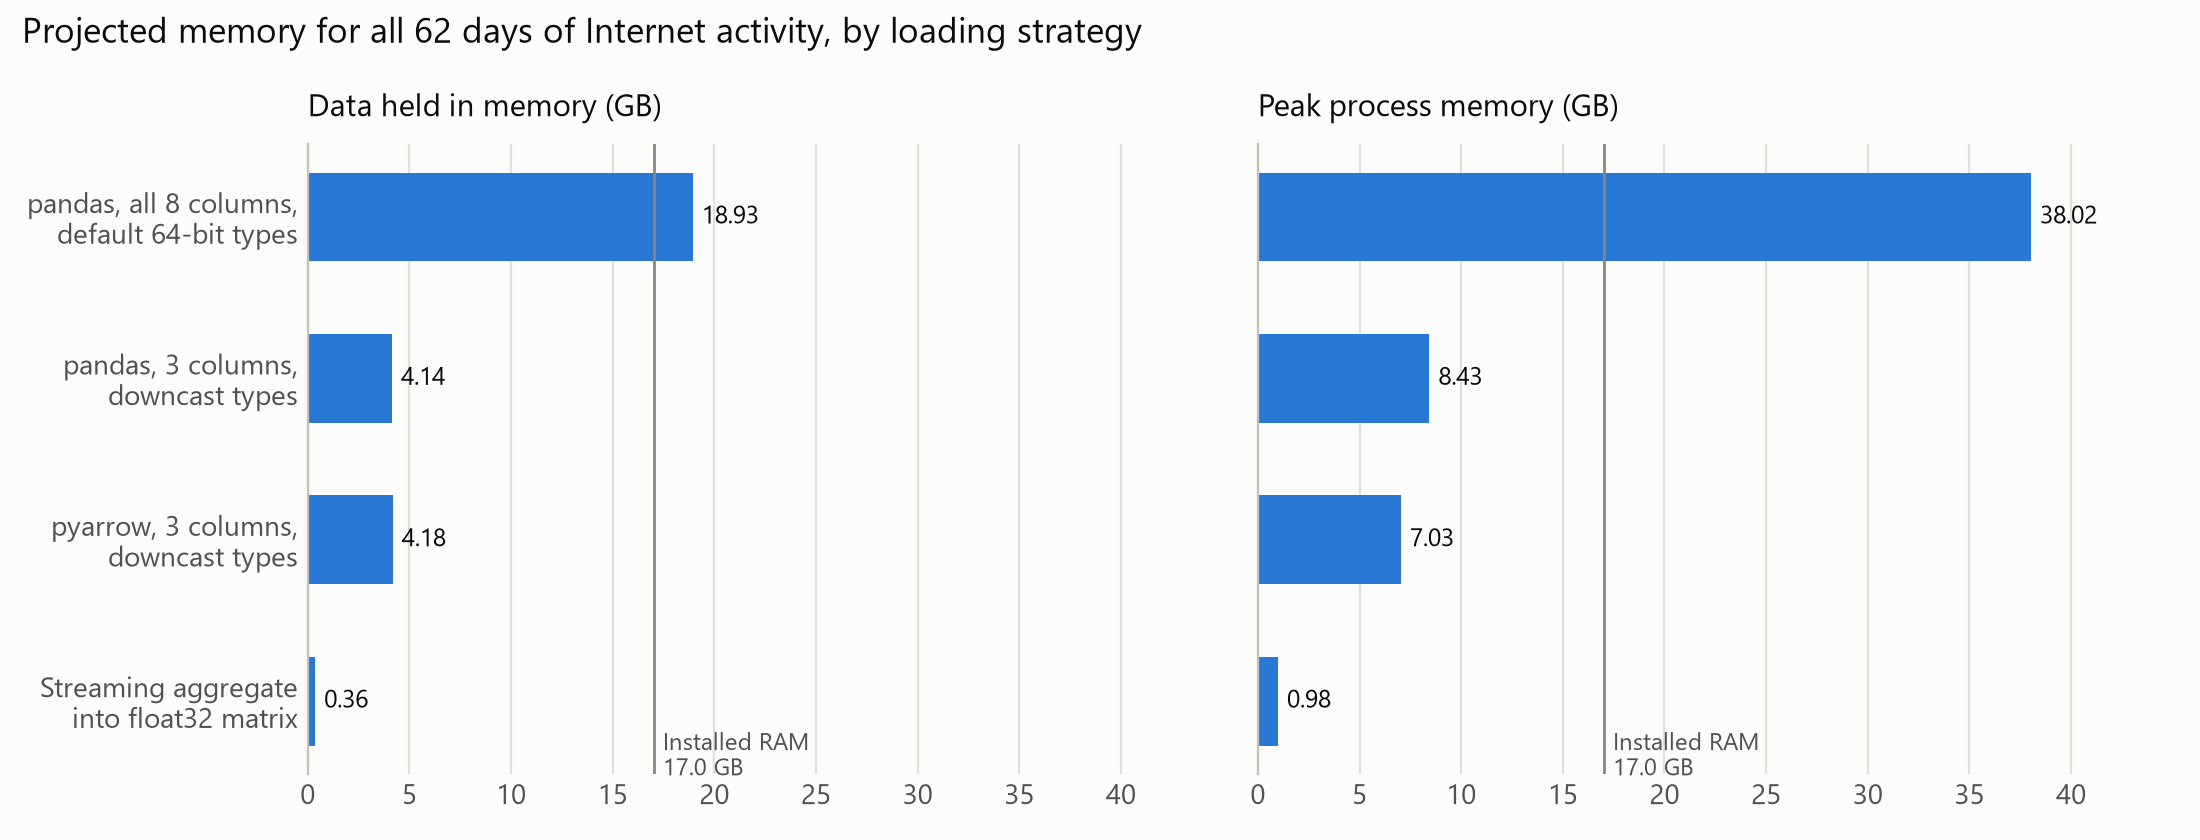

In [5]:
show(config.DATA_HANDLING_DIR / "memory_benchmark.png")

If the processed matrix exists on this machine, the next cell opens it memory-mapped and reads the
busiest square. Process memory barely moves, because only that one row (about 36 KB) is loaded.

In [6]:
if config.MATRIX_PATH.exists():
    from milan_forecasting.data.loader import load_internet_matrix, square_series
    from milan_forecasting.data.memory import current_rss_mb

    before = current_rss_mb()
    matrix, timestamps = load_internet_matrix(mmap=True)
    busiest = square_series(matrix, timestamps, 5161)
    after = current_rss_mb()
    print(f"matrix {matrix.shape}, {matrix.dtype}, {matrix.nbytes / 1e6:.0f} MB on disk")
    print(f"process memory {before:.0f} MB -> {after:.0f} MB after reading square 5161")
    display(busiest.describe().round(1).to_frame())
else:
    print("Processed matrix not found. Run scripts/01_build_dataset.py to try this cell.")

matrix (10000, 8928), float32, 357 MB on disk
process memory 120 MB -> 120 MB after reading square 5161


,square_5161
count,8928.0
mean,1427.0
std,1381.6
min,55.8
25%,236.6
50%,859.5
75%,2460.1
max,8044.1


## 2. What the traffic looks like

Traffic is spread very unevenly across the city. A few central squares carry a large share of
it, and the totals look close to log-normal: the raw skew almost disappears once you take logs.

In [7]:
stats = read_json(config.ANALYSIS_DIR / "statistics.json")
distribution = pd.Series(stats["distribution"])
distribution[["mean", "median", "max_to_median", "skewness", "skewness_log10", "gini",
              "top_1pct_share", "top_10pct_share", "bottom_50pct_share"]].round(3).to_frame("value")

,value
mean,555289.419
median,277871.101
max_to_median,45.849
skewness,4.265
skewness_log10,0.023
gini,0.608
top_1pct_share,0.110
top_10pct_share,0.484
bottom_50pct_share,0.116


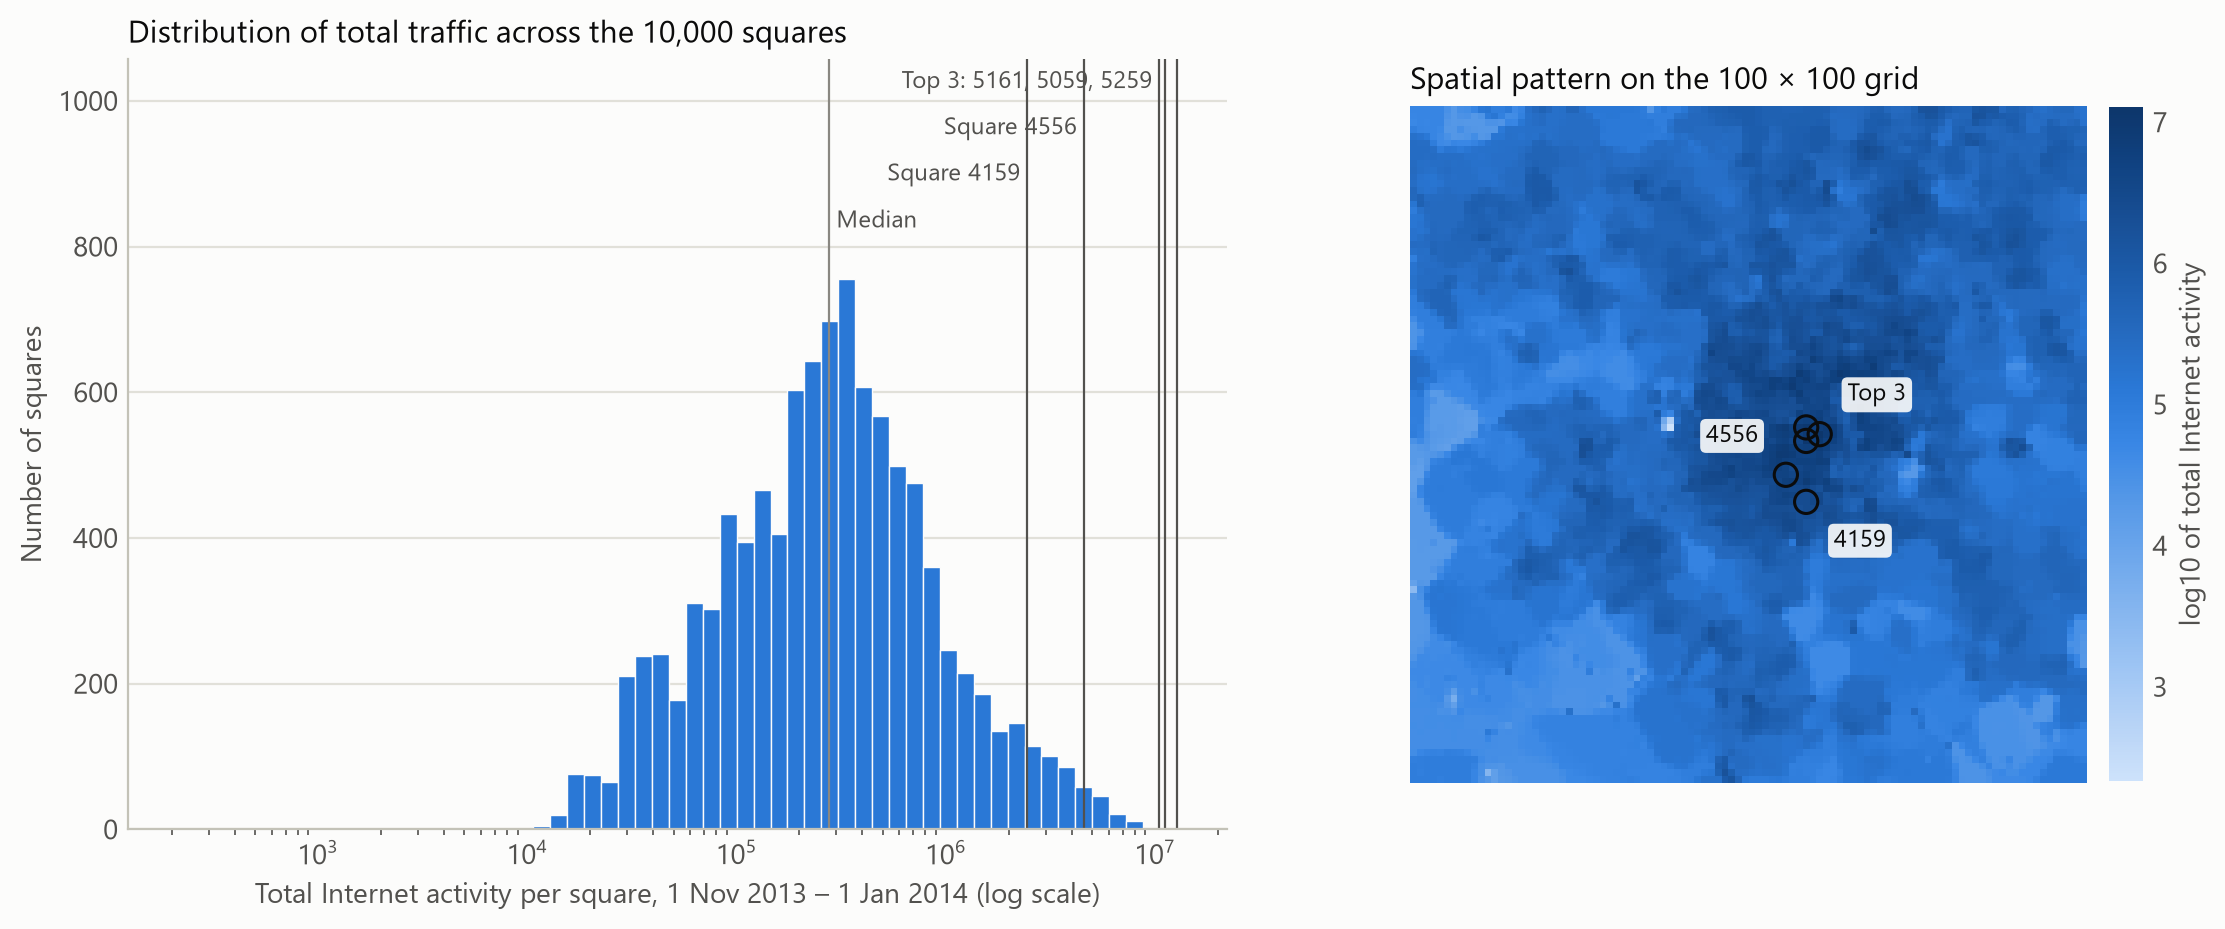

In [8]:
show(config.ANALYSIS_DIR / "traffic_distribution.png")

The five areas the brief asks about share a strong daily rhythm but behave differently at
weekends. Square 5161 gets busier, 5259 empties out like an office district, and 4556 peaks late
in the evening.

In [9]:
profiles = pd.DataFrame({
    square: {"rank": stats["ranks"][square], **values["full_period"]}
    for square, values in stats["temporal_profiles"].items()
}).T
profiles[["rank", "mean", "peak_hour", "trough_hour", "peak_to_trough_ratio",
          "weekend_to_weekday_ratio", "lag1_autocorrelation", "lag144_autocorrelation"]].round(2)

,rank,mean,peak_hour,trough_hour,peak_to_trough_ratio,weekend_to_weekday_ratio,lag1_autocorrelation,lag144_autocorrelation
5161,1.0,1426.98,16.0,4.0,19.68,1.38,0.99,0.89
5059,2.0,1251.22,14.0,4.0,9.09,0.86,0.98,0.91
5259,3.0,1174.48,13.0,6.0,7.72,0.43,0.99,0.70
4159,424.0,274.88,12.0,5.0,3.69,0.59,0.98,0.79
4556,109.0,512.40,22.0,5.0,3.81,1.14,0.96,0.82


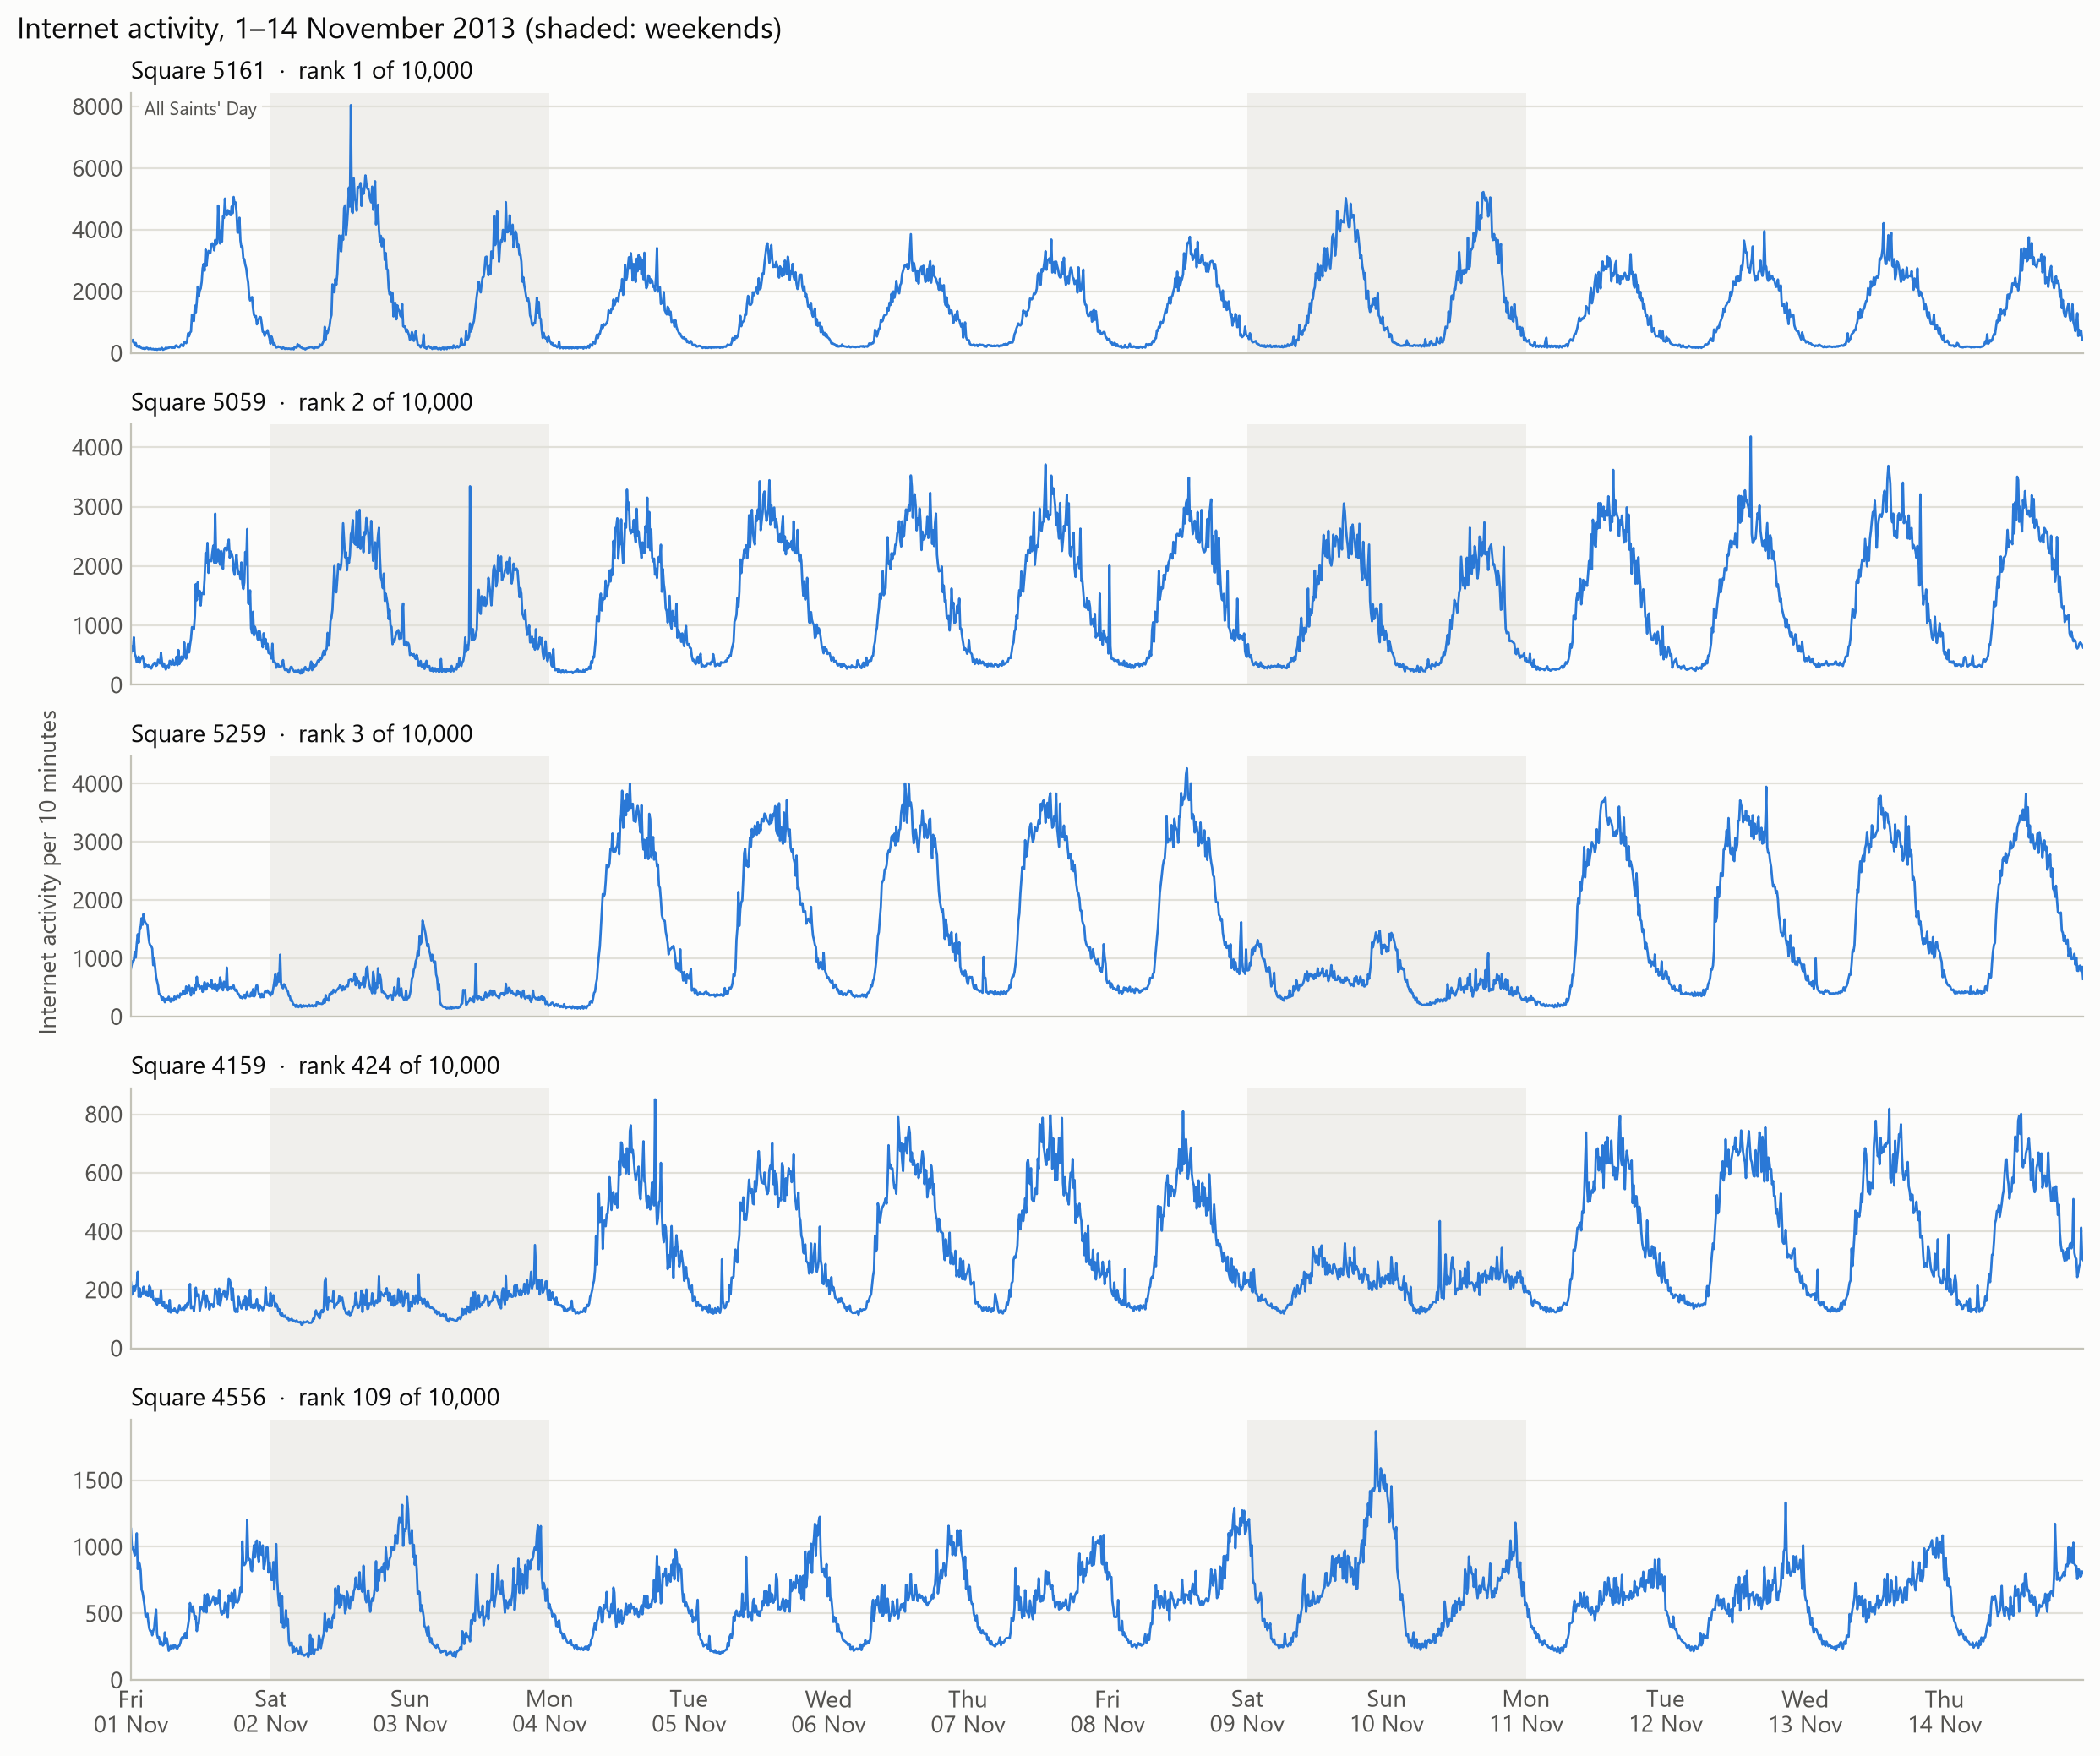

In [10]:
show(config.ANALYSIS_DIR / "first_two_weeks.png")

For the busiest square, the value ten minutes ago is almost the same as the value now, and the
same time yesterday and the same time last week are both strong guides. That is what pushed the
models towards a one-day input window and a same-time-yesterday baseline.

In [11]:
busiest = stats["busiest_square"]
acf = pd.Series(busiest["acf"]).rename(lambda lag: lag.replace("lag_", "lag "))
display(acf.round(3).to_frame("autocorrelation"))
print("PACF, lags 1-6:", [round(v, 3) for v in busiest["pacf_first_12"][:6]])

,autocorrelation
lag 1,0.987
lag 6,0.939
lag 36,0.010
lag 72,-0.683
lag 144,0.878
lag 432,0.741
lag 1008,0.838
lag 2016,0.705


PACF, lags 1-6: [0.987, 0.26, 0.046, -0.147, -0.15, -0.146]


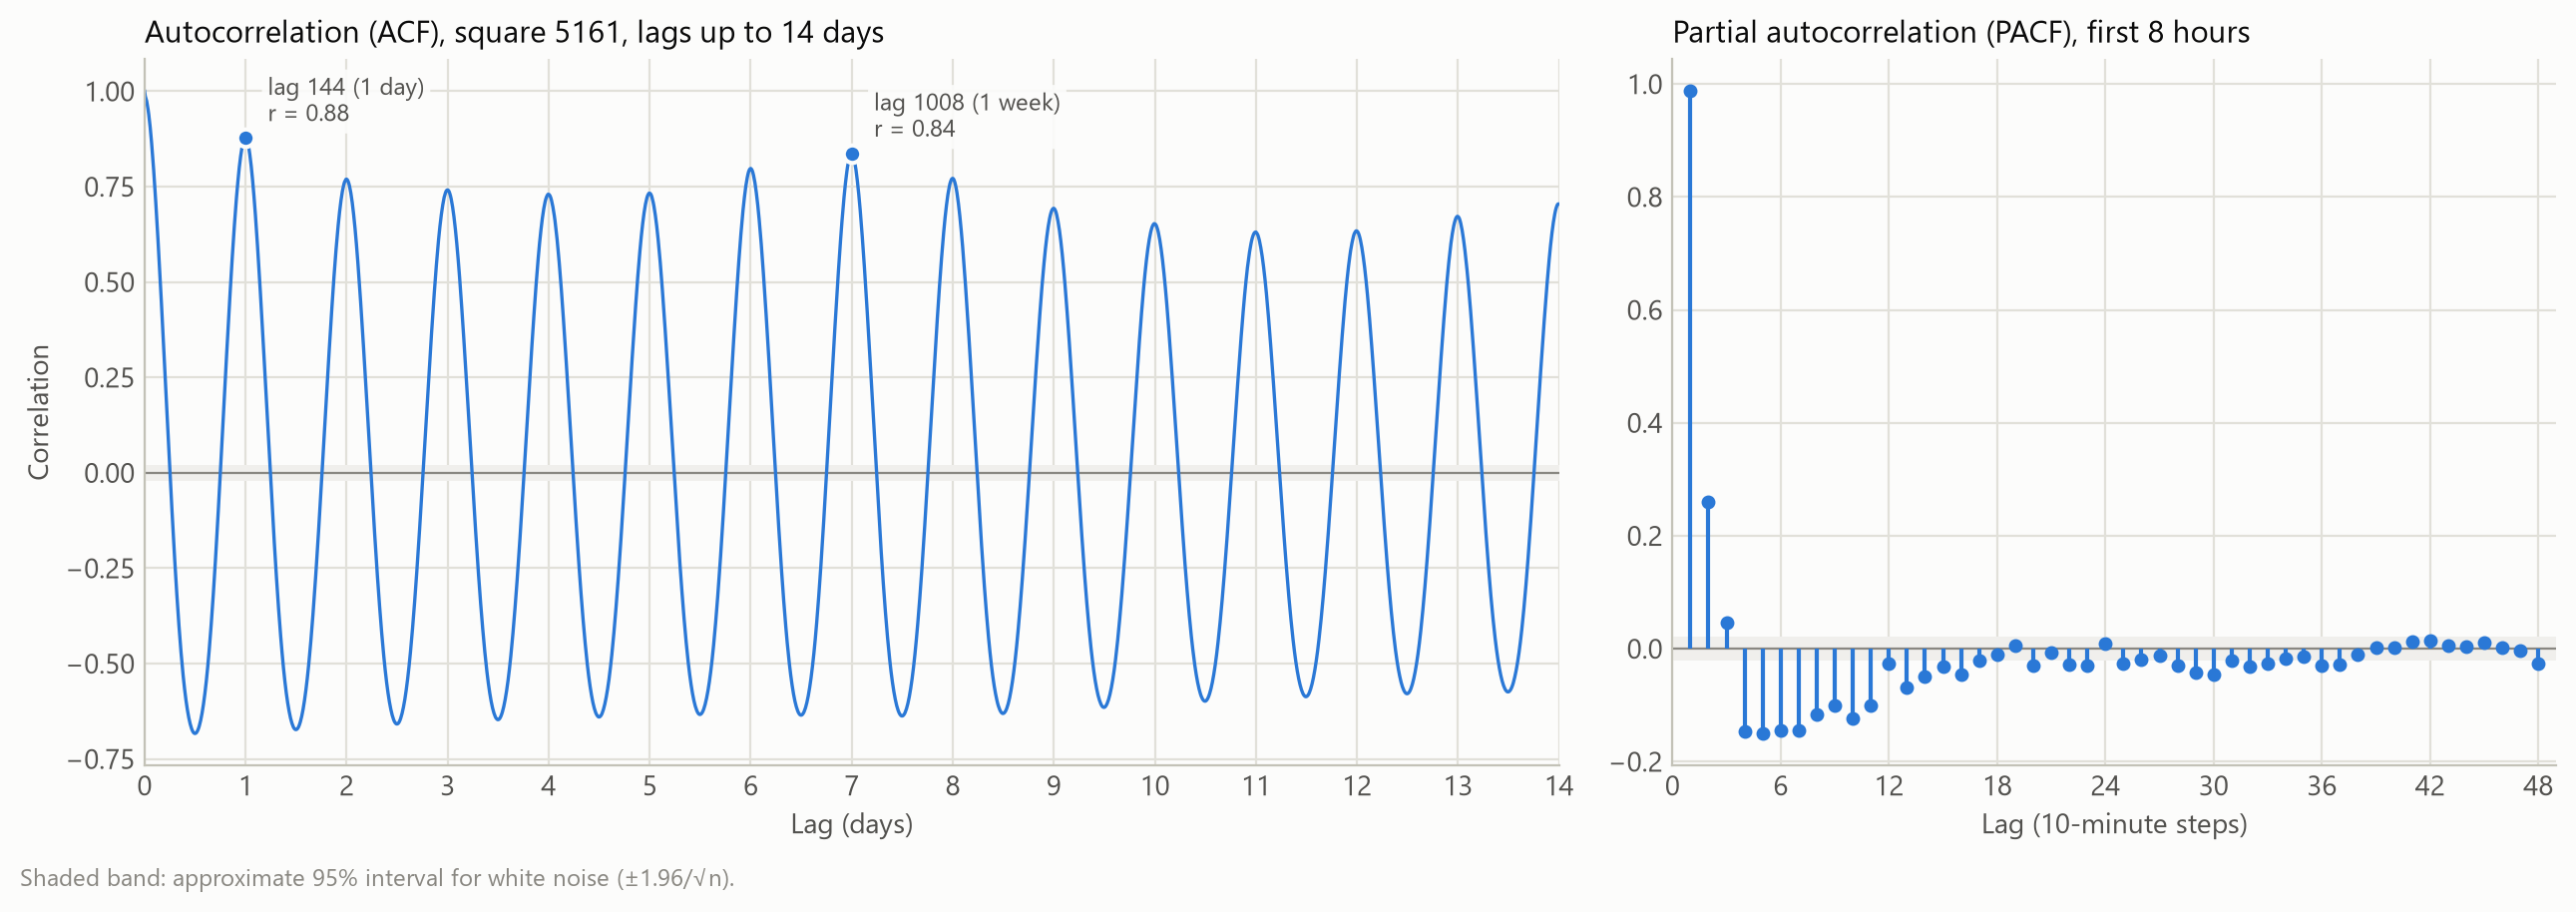

In [12]:
show(config.ANALYSIS_DIR / "autocorrelation.png")

Busy days swing harder than quiet ones, so the seasonality is multiplicative. Decomposing the raw
series left residuals whose spread changed a lot with the hour of day; on the log scale that
problem mostly goes away. The same finding is why every model works on log traffic.

In [13]:
evidence = busiest["multiplicative_seasonality"]
pd.DataFrame({
    "raw": evidence["raw"],
    "log(1 + x)": evidence["log1p"],
}).round(3)

,raw,log(1 + x)
residual_std_max_to_min_by_hour,16.984,1.944
corr_fitted_level_vs_abs_residual,0.553,-0.016
anomaly_share,0.123,0.022


In [14]:
print("seasonal and trend strength (robust MSTL on log traffic):")
display(pd.Series(busiest["component_strengths"]).round(3).to_frame("strength"))
stationarity = pd.DataFrame(busiest["stationarity"]).T
stationarity[["adf_statistic", "adf_p_value", "adf_lags_used", "kpss_statistic", "kpss_p_value", "kpss_lags_used"]]

seasonal and trend strength (robust MSTL on log traffic):


,strength
trend,0.503
daily_seasonality,0.949
weekly_seasonality,0.455


,adf_statistic,adf_p_value,adf_lags_used,kpss_statistic,kpss_p_value,kpss_lags_used
level,-19.032,0.0,36,0.237,0.1,56
first_difference,-15.16,0.0,37,0.003,0.1,44
daily_seasonal_difference,-11.833,0.0,30,0.069,0.1,55


The stationarity tests say there is no random-walk drift, but their lag windows only reach back
six and nine hours, so they cannot see the daily cycle or the drop in traffic before Christmas.
The decomposition shows both clearly.

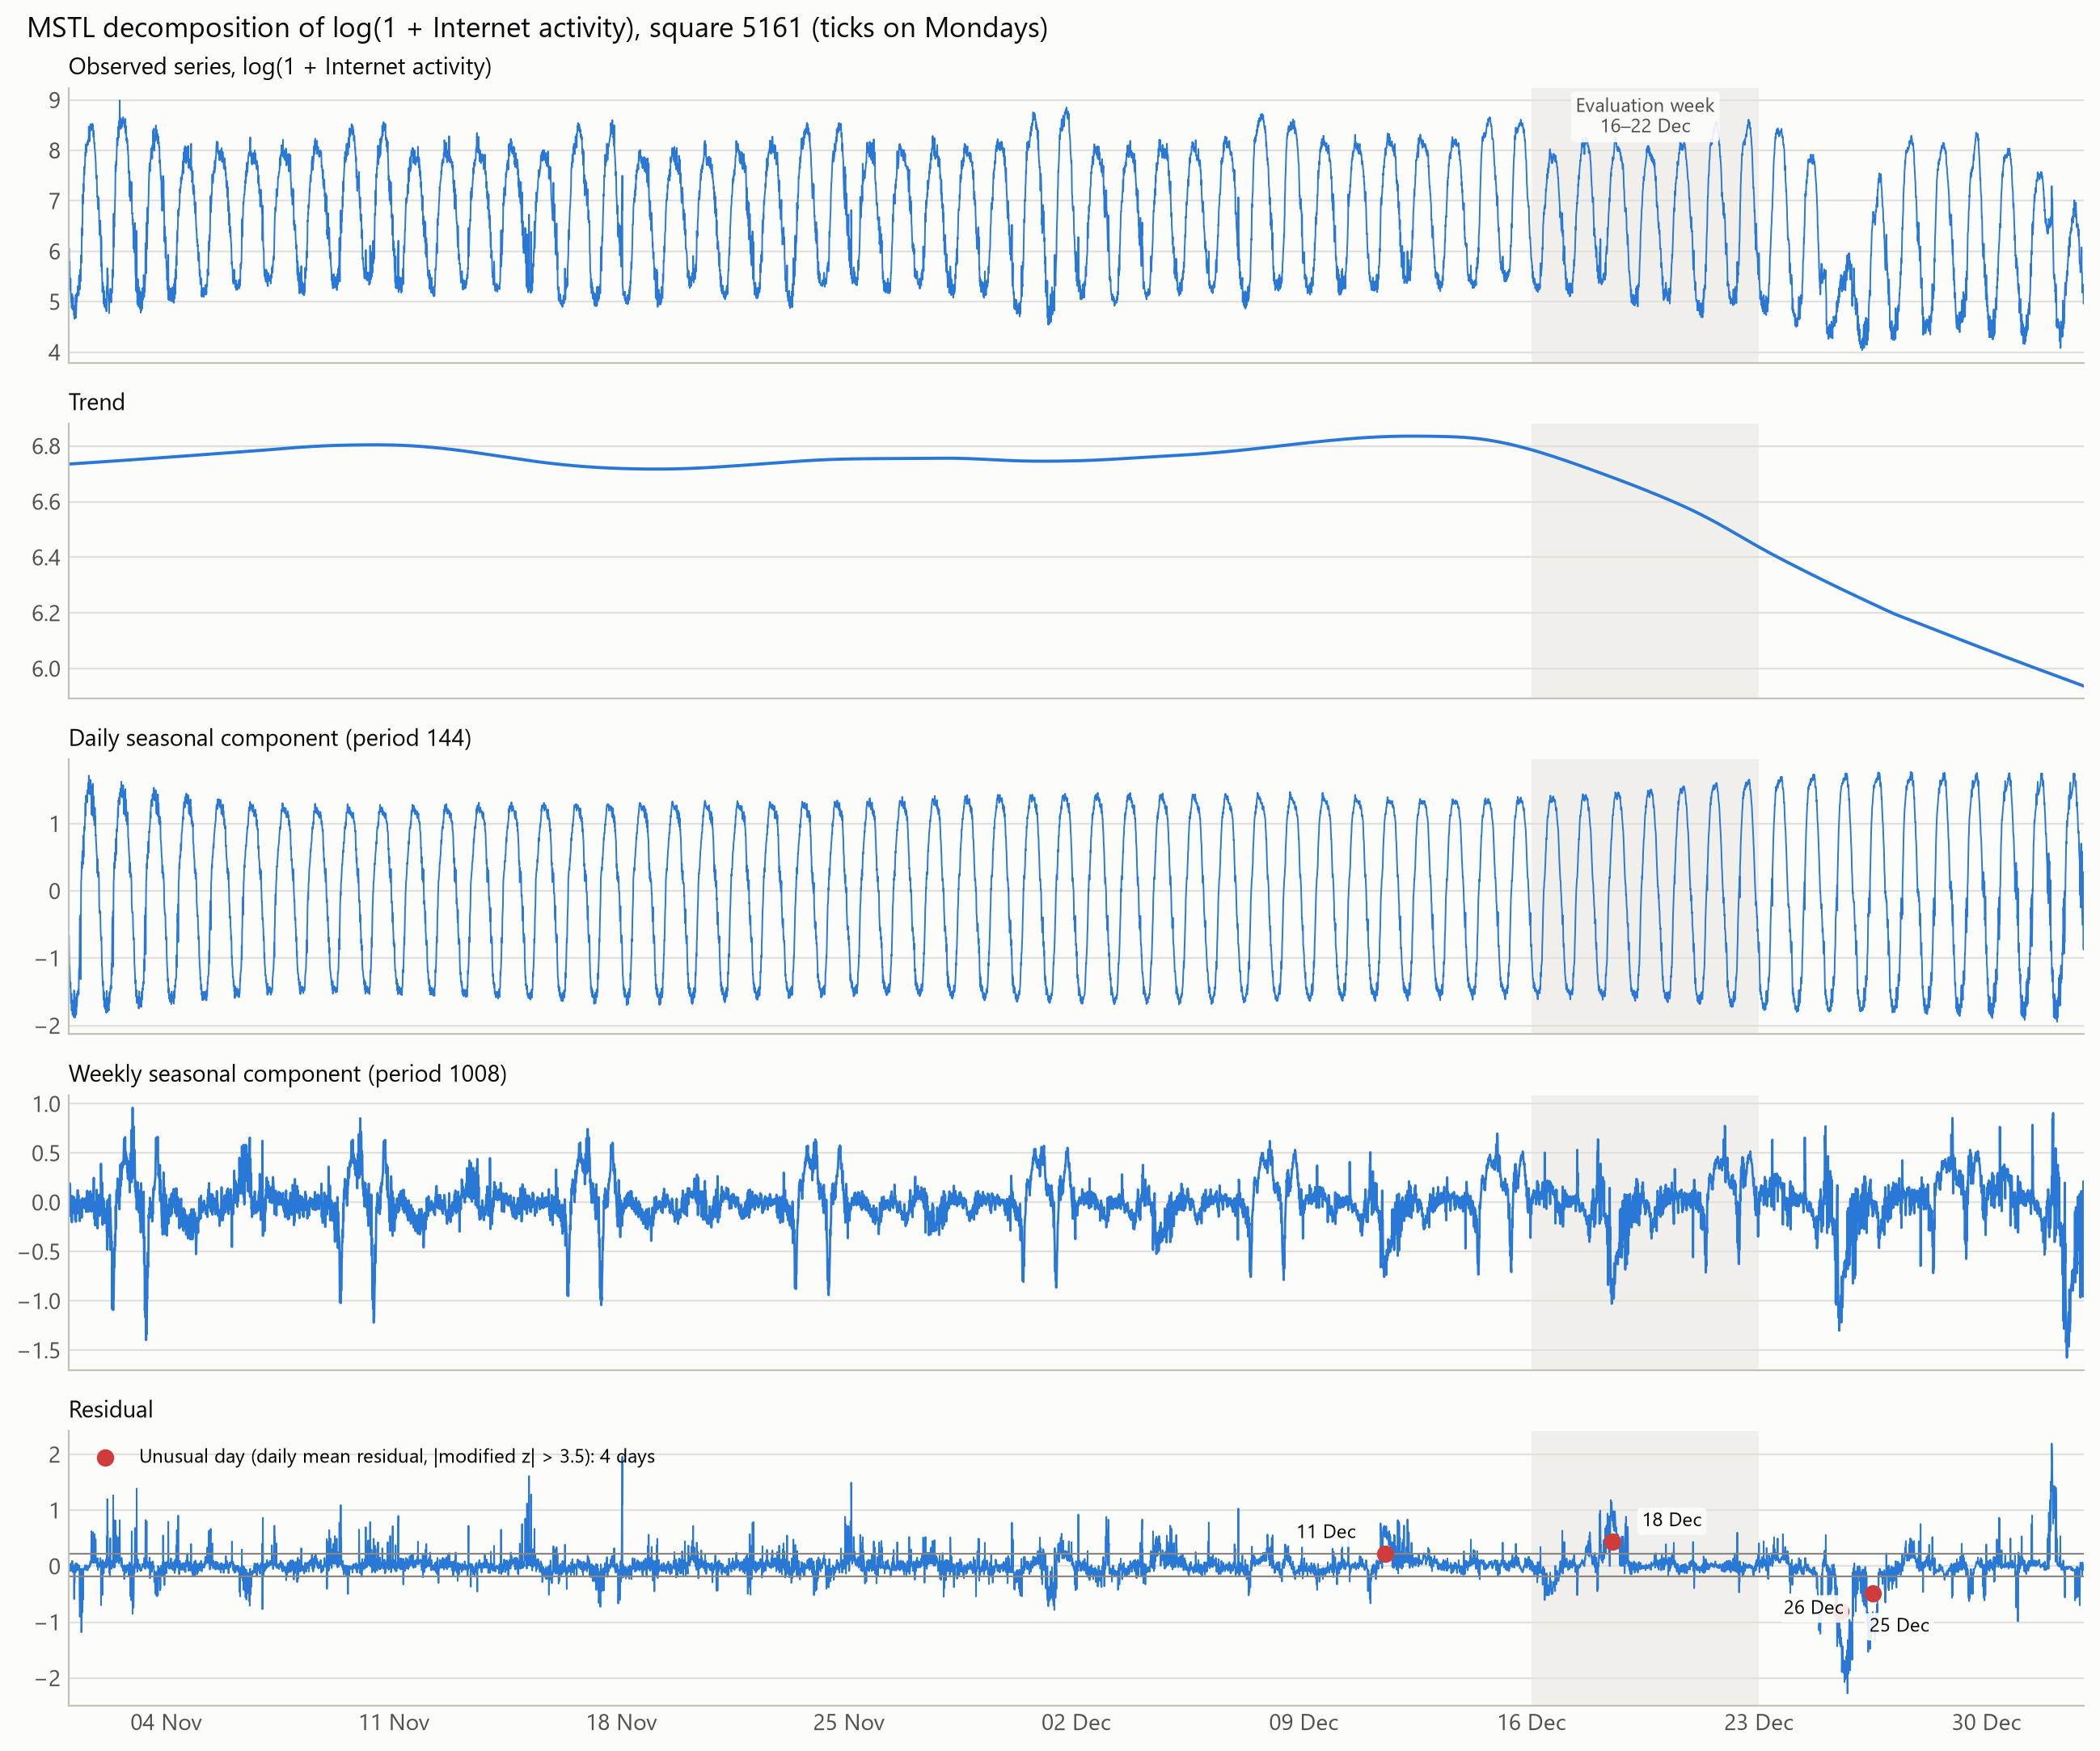

In [15]:
show(config.ANALYSIS_DIR / "decomposition.png")

In [16]:
unusual = pd.DataFrame(busiest["unusual_days"]["flagged"])
unusual.round(3)

,date,mean_residual,z_score,holiday
0,2013-12-25,-0.810,-14.150,Christmas Day
1,2013-12-26,-0.491,-8.694,St Stephen's Day
2,2013-12-18,0.435,7.179,
3,2013-12-11,0.222,3.531,


Robust fitting was chosen after comparing it with the default fit. The default fit quietly
absorbed part of the Christmas dip into its seasonal pattern, while the robust one left it
visible as an unusual day.

In [17]:
experiment = read_json(config.ANALYSIS_DIR / "decomposition_experiment.json")
rows = ["fit_seconds", "residual_mad", "residual_std", "christmas_mean_residual", "christmas_min_residual",
        "anomaly_points", "days_with_anomalies"]
pd.DataFrame({fit: {k: experiment[fit][k] for k in rows} for fit in ("default", "robust")}).round(3)

,default,robust
fit_seconds,42.600,259.900
residual_mad,0.096,0.066
residual_std,0.194,0.261
christmas_mean_residual,-0.582,-0.810
christmas_min_residual,-1.297,-2.276
anomaly_points,196.000,900.000
days_with_anomalies,24.000,60.000


## 3. Models and tuning

Three models from different families are compared against a same-time-yesterday baseline: ARIMA
with Fourier terms for the daily and weekly cycles, an LSTM, and a TCN. The data is split in
time: training up to 8 December, validation on 9-15 December, testing on 16-22 December.

Tuning used only the validation week of square 5161. Each run changed one setting, and the
reason was written into the log before seeing the result. A model's tuning stopped once a change
improved validation MAE by less than 1%. After the manual runs, a grid search over the ARIMA
orders p and q (the last nine rows of the log) found that dropping the MA term, ARIMA(2,1,0),
lowered validation MAE by 3.5%, so that order became the final one.

In [18]:
final_configs = read_json(config.FINAL_MODELS_CONFIG)
print(json.dumps(final_configs, indent=2))

{
  "arima": {
    "p": 2,
    "d": 1,
    "q": 0,
    "daily_harmonics": 16,
    "weekly_harmonics": 8
  },
  "lstm": {
    "lookback": 144,
    "batch_size": 128,
    "learning_rate": 0.0005,
    "max_epochs": 80,
    "patience": 10,
    "model": {
      "hidden_size": 64,
      "num_layers": 1
    }
  },
  "tcn": {
    "lookback": 144,
    "batch_size": 128,
    "learning_rate": 0.001,
    "max_epochs": 80,
    "patience": 6,
    "model": {
      "channels": 16,
      "levels": 6,
      "kernel_size": 3,
      "dropout": 0.1
    }
  }
}


In [19]:
log = pd.read_csv(config.EXPERIMENT_LOG)
log[["run_id", "model", "mae", "rmse", "mape", "train_seconds", "parameters", "converged", "note"]]

,run_id,model,mae,rmse,mape,train_seconds,parameters,converged,note
0,20260916-103038-naive,naive,294.894,525.494,18.334,0.00,NaN,NaN,"Baseline: same time yesterday (lag 144). ACF at lag 144 is 0.88, so this is the bar every model must beat."
1,20260916-103212-arima,arima,101.818,156.530,7.643,61.42,29.0,True,"ARIMA starting point: PACF cuts off after lag 2, so ARMA(2,1) errors; 8 daily and 4 weekly Fourier pairs as a modera..."
2,20260916-103523-lstm,lstm,112.554,172.895,8.025,136.12,17217.0,NaN,"LSTM starting point: one-day window (ACF 0.88 at lag 144), single layer of 64 units as a small model for ~5.3k train..."
3,20260916-104311-tcn,tcn,105.334,160.514,7.636,430.68,34369.0,NaN,TCN starting point: same one-day window as the LSTM for a fair first comparison; 6 levels of kernel 3 give a 253-ste...
4,20260916-104607-arima,arima,101.017,155.241,7.574,96.68,45.0,True,"Round 1: daily harmonics 8 -> 16. The daily profile is sharp (17x peak-to-trough in raw traffic), so 8 Fourier pairs..."
5,20260916-114935-lstm,lstm,109.516,166.721,8.184,3791.72,17217.0,NaN,"Round 1: lookback 144 -> 1008. ACF is 0.84 at one week vs 0.74 at three days, so a week of context should let the LS..."
6,20260916-115457-tcn,tcn,100.674,154.368,7.576,300.23,8737.0,NaN,Round 1: channels 32 -> 16. The first TCN took 31 s/epoch on 2 CPU cores (6x the LSTM) and peaked at epoch 8; test w...
7,20260916-115626-arima,arima,1061.119,1521.493,78.298,22.35,53.0,False,Round 2: weekly harmonics 4 -> 8 (keeping 16 daily). Weekly seasonal strength was 0.63 in the EDA (default decomposi...
8,20260916-115855-lstm,lstm,109.694,168.250,8.058,134.61,17217.0,NaN,Round 2: back to lookback 144 (1008 cost 28x the time for 3% MAE and worse MAPE). Learning rate 1e-3 -> 5e-4 with pa...
9,20260916-120727-tcn,tcn,100.674,154.368,7.576,492.69,8737.0,NaN,Round 2: max epochs 40 -> 80. The 16-channel TCN beat the 32-channel one and was still improving when it hit the 40-...


The ARIMA run with 1,061 MAE is the one that failed. The 7th weekly Fourier wave is the same as
the 1st daily wave (a week is exactly seven days), which made two regressors identical and
stopped the optimiser before it started. Removing the duplicates fixed it, as the next ARIMA run
shows.

These are the validation runs of the configurations that were kept. The one-week LSTM had a
slightly lower validation MAE (109.5 against 109.7), but it took 28 times as long to train and its
MAPE was worse, so the one-day version went forward.

In [20]:
def matches(params, chosen):
    return all(
        matches(params.get(key, {}), value) if isinstance(value, dict) else params.get(key) == value
        for key, value in chosen.items()
    )


chosen = {"naive": {}, **final_configs}
kept = pd.concat([
    log[(log["model"] == model) & log["params"].map(lambda p: matches(json.loads(p), settings))].tail(1)
    for model, settings in chosen.items()
])
kept[["model", "run_id", "mae", "rmse", "mape", "train_seconds"]].sort_values("mae").reset_index(drop=True)

,model,run_id,mae,rmse,mape,train_seconds
0,arima,20260916-184023-arima,96.618,147.568,7.533,15.40
1,tcn,20260916-120727-tcn,100.674,154.368,7.576,492.69
2,lstm,20260916-115855-lstm,109.694,168.250,8.058,134.61
3,naive,20260916-103038-naive,294.894,525.494,18.334,0.00


## 4. Results on the test week

The test week was only used once, after tuning had finished. The networks were trained with
three different seeds, so the tables show their mean and spread.

In [21]:
display(Markdown((config.EVALUATION_DIR / "results_tables.md").read_text(encoding="utf-8")))

### Square 5161

| Model | MAE | MAPE (%) | RMSE | MASE |
|---|---|---|---|---|
| Seasonal naive | 338.59 | 25.94 | 619.04 | 0.975 |
| ARIMA-Fourier | 76.86 | 7.33 | 117.12 | 0.221 |
| LSTM | 92.53 ± 1.94 | 8.48 ± 0.04 | 144.31 ± 3.12 | 0.266 ± 0.006 |
| TCN | 87.74 ± 0.69 | 8.60 ± 0.63 | 132.10 ± 3.52 | 0.253 ± 0.002 |

### Square 5059

| Model | MAE | MAPE (%) | RMSE | MASE |
|---|---|---|---|---|
| Seasonal naive | 171.74 | 18.02 | 245.87 | 0.635 |
| ARIMA-Fourier | 63.86 | 6.11 | 93.33 | 0.236 |
| LSTM | 69.58 ± 2.41 | 6.72 ± 0.24 | 102.17 ± 3.76 | 0.257 ± 0.009 |
| TCN | 73.31 ± 4.75 | 7.50 ± 0.99 | 104.32 ± 4.68 | 0.271 ± 0.018 |

### Square 5259

| Model | MAE | MAPE (%) | RMSE | MASE |
|---|---|---|---|---|
| Seasonal naive | 470.32 | 71.62 | 861.62 | 0.898 |
| ARIMA-Fourier | 63.20 | 6.83 | 92.70 | 0.121 |
| LSTM | 66.63 ± 0.33 | 7.24 ± 0.11 | 96.00 ± 1.44 | 0.127 ± 0.001 |
| TCN | 68.86 ± 9.80 | 7.24 ± 0.39 | 103.54 ± 20.31 | 0.131 ± 0.019 |

Networks: mean ± standard deviation over seeds. ARIMA and the baseline are deterministic.


Comparing validation with test for square 5161 shows why a separate test week matters. ARIMA's
percentage error hardly changed, while both networks got worse. Their early stopping had been
tuned on the validation week, so their validation scores flattered them a little.

In [22]:
runs = pd.read_csv(config.EVALUATION_DIR / "metrics_all_runs.csv")
test_5161 = runs[runs["square"] == 5161].groupby("model")["mape"].mean()
validation = kept.set_index("model")["mape"]
comparison = pd.DataFrame({"validation MAPE (%)": validation, "test MAPE (%)": test_5161}).dropna()
comparison["change (%)"] = 100 * (comparison["test MAPE (%)"] / comparison["validation MAPE (%)"] - 1)
comparison.round(2)

,validation MAPE (%),test MAPE (%),change (%)
model,,,
arima,7.53,7.33,-2.75
lstm,8.06,8.48,5.17
naive,18.33,25.94,41.49
tcn,7.58,8.60,13.56


Are these gaps bigger than chance? Diebold-Mariano tests compare two models' errors on the same
1,008 forecasts, allowing for the fact that neighbouring 10-minute errors are correlated. A
negative statistic means the first model has the lower error. Nine pairs are tested per loss
function, so p-values are adjusted with Holm-Bonferroni within each loss function. ARIMA is
significantly better in three of the six comparisons with the networks: both networks in 5161
and the TCN in 5059. The ARIMA-vs-LSTM gaps in 5059 and 5259 do not survive correction, and in
5259 ARIMA is level with the TCN.

In [23]:
display(Markdown((config.EVALUATION_DIR / "significance.md").read_text(encoding="utf-8")))

Diebold-Mariano tests on the test week (1,008 one-step forecasts per square; networks: seed 42).
Negative statistic: model A has the lower loss. Newey-West variance, HLN-adjusted, t(n-1) p-values.
* p < 0.05, ** p < 0.01, *** p < 0.001.

| Square | A vs B | DM, absolute loss | p | DM, squared loss | p |
|---|---|---:|---:|---:|---:|
| 5161 | ARIMA-Fourier vs LSTM | -4.76*** | 2.2e-06 | -4.23*** | 2.55e-05 |
| 5161 | ARIMA-Fourier vs TCN | -4.35*** | 1.49e-05 | -3.81*** | 0.00015 |
| 5161 | LSTM vs TCN | 1.99* | 0.047 | 2.70** | 0.00714 |
| 5059 | ARIMA-Fourier vs LSTM | -2.12* | 0.0341 | -2.04* | 0.0413 |
| 5059 | ARIMA-Fourier vs TCN | -3.76*** | 0.000177 | -2.96** | 0.00317 |
| 5059 | LSTM vs TCN | -1.43 | 0.152 | -0.63 | 0.529 |
| 5259 | ARIMA-Fourier vs LSTM | -2.28* | 0.0227 | -1.80 | 0.072 |
| 5259 | ARIMA-Fourier vs TCN | 0.53 | 0.598 | 0.78 | 0.433 |
| 5259 | LSTM vs TCN | 3.04** | 0.00243 | 3.11** | 0.00192 |


In [24]:
timing = read_json(config.EVALUATION_DIR / "timing.json")
print("hardware:", ", ".join(f"{k}={v}" for k, v in timing["hardware"].items()))
print()
print(timing["method"])
pd.DataFrame(timing["by_model"]).T

hardware: cpu=Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, physical_cores=2, logical_cores=4, ram_gb=17.0, gpu_used=False, cuda_available=False, torch_threads=2, os=Windows-10-10.0.19045-SP0, python=3.14.2, torch=2.14.0+cpu, statsmodels=0.15.0

Wall-clock time from time.perf_counter. Training time covers fitting on the training split (for the networks: all epochs including early stopping on the validation split). Prediction time covers producing all 1,008 one-step-ahead forecasts of the test week. Networks: one measurement per seed per square; ARIMA and baseline: repeated runs per square. Reported as the median with min-max over all measurements for the model across the three squares. CPU only.


,measurements,train_seconds_median,train_seconds_min,train_seconds_max,predict_ms_per_step_median,predict_ms_per_step_min,predict_ms_per_step_max
naive,3.0,0.00,0.00,0.00,0.000,0.000,0.000
arima,9.0,18.61,12.08,25.45,0.118,0.114,0.141
lstm,9.0,189.93,111.63,282.23,0.186,0.144,0.431
tcn,9.0,222.08,128.81,496.57,0.144,0.123,0.389


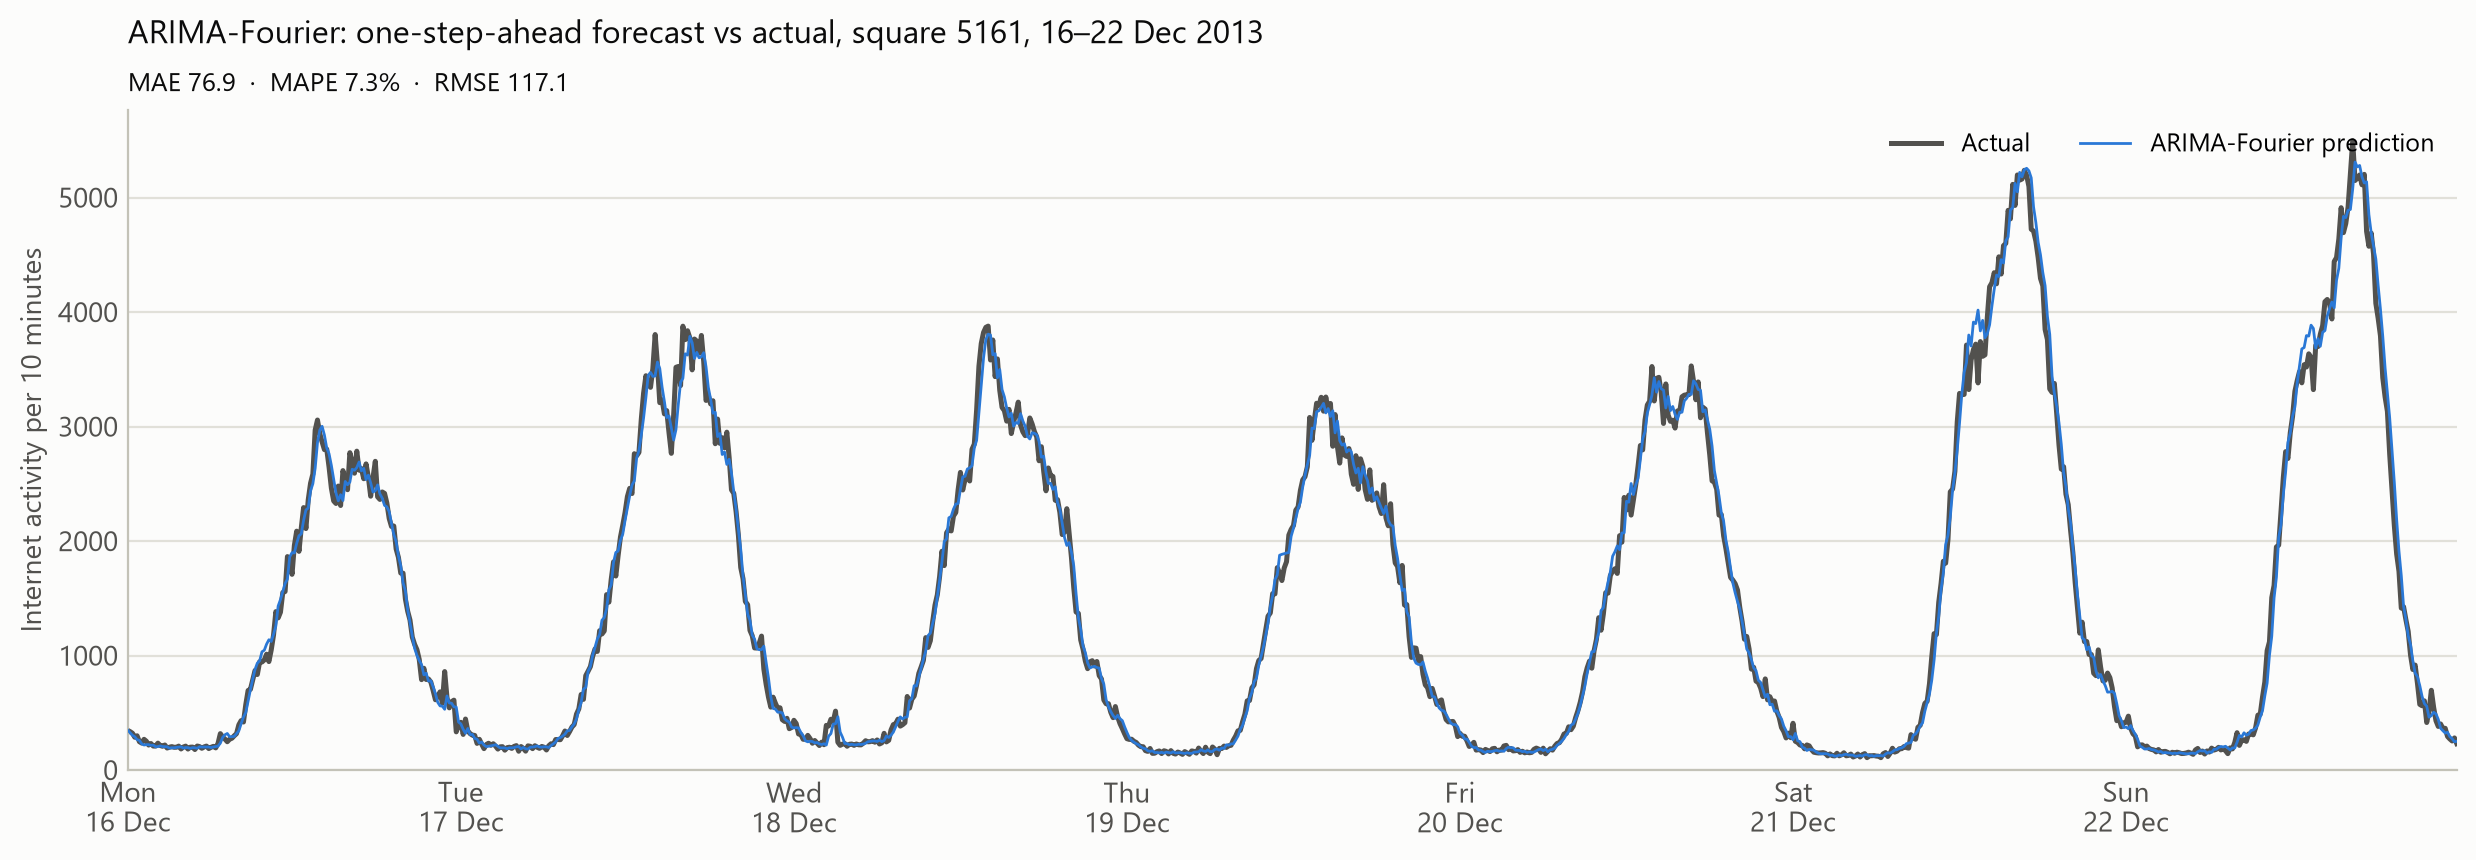

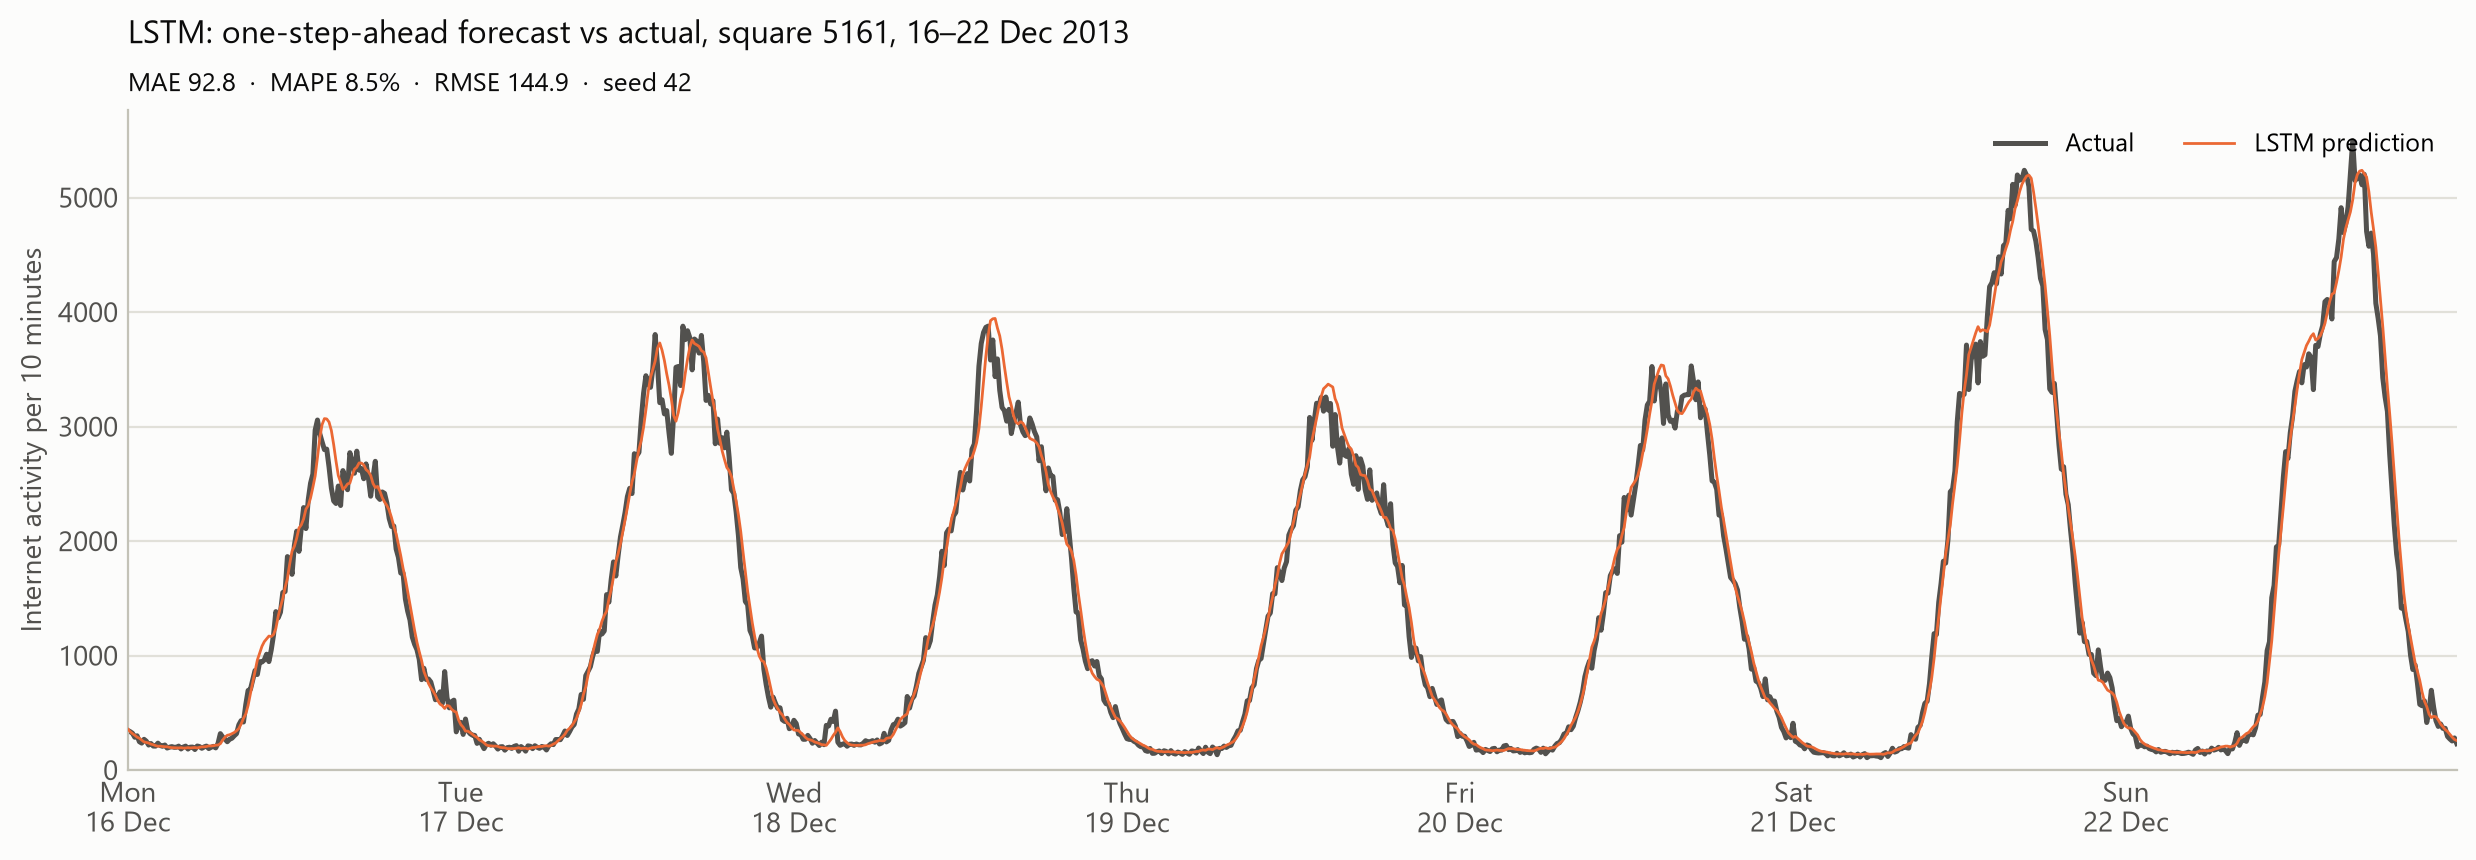

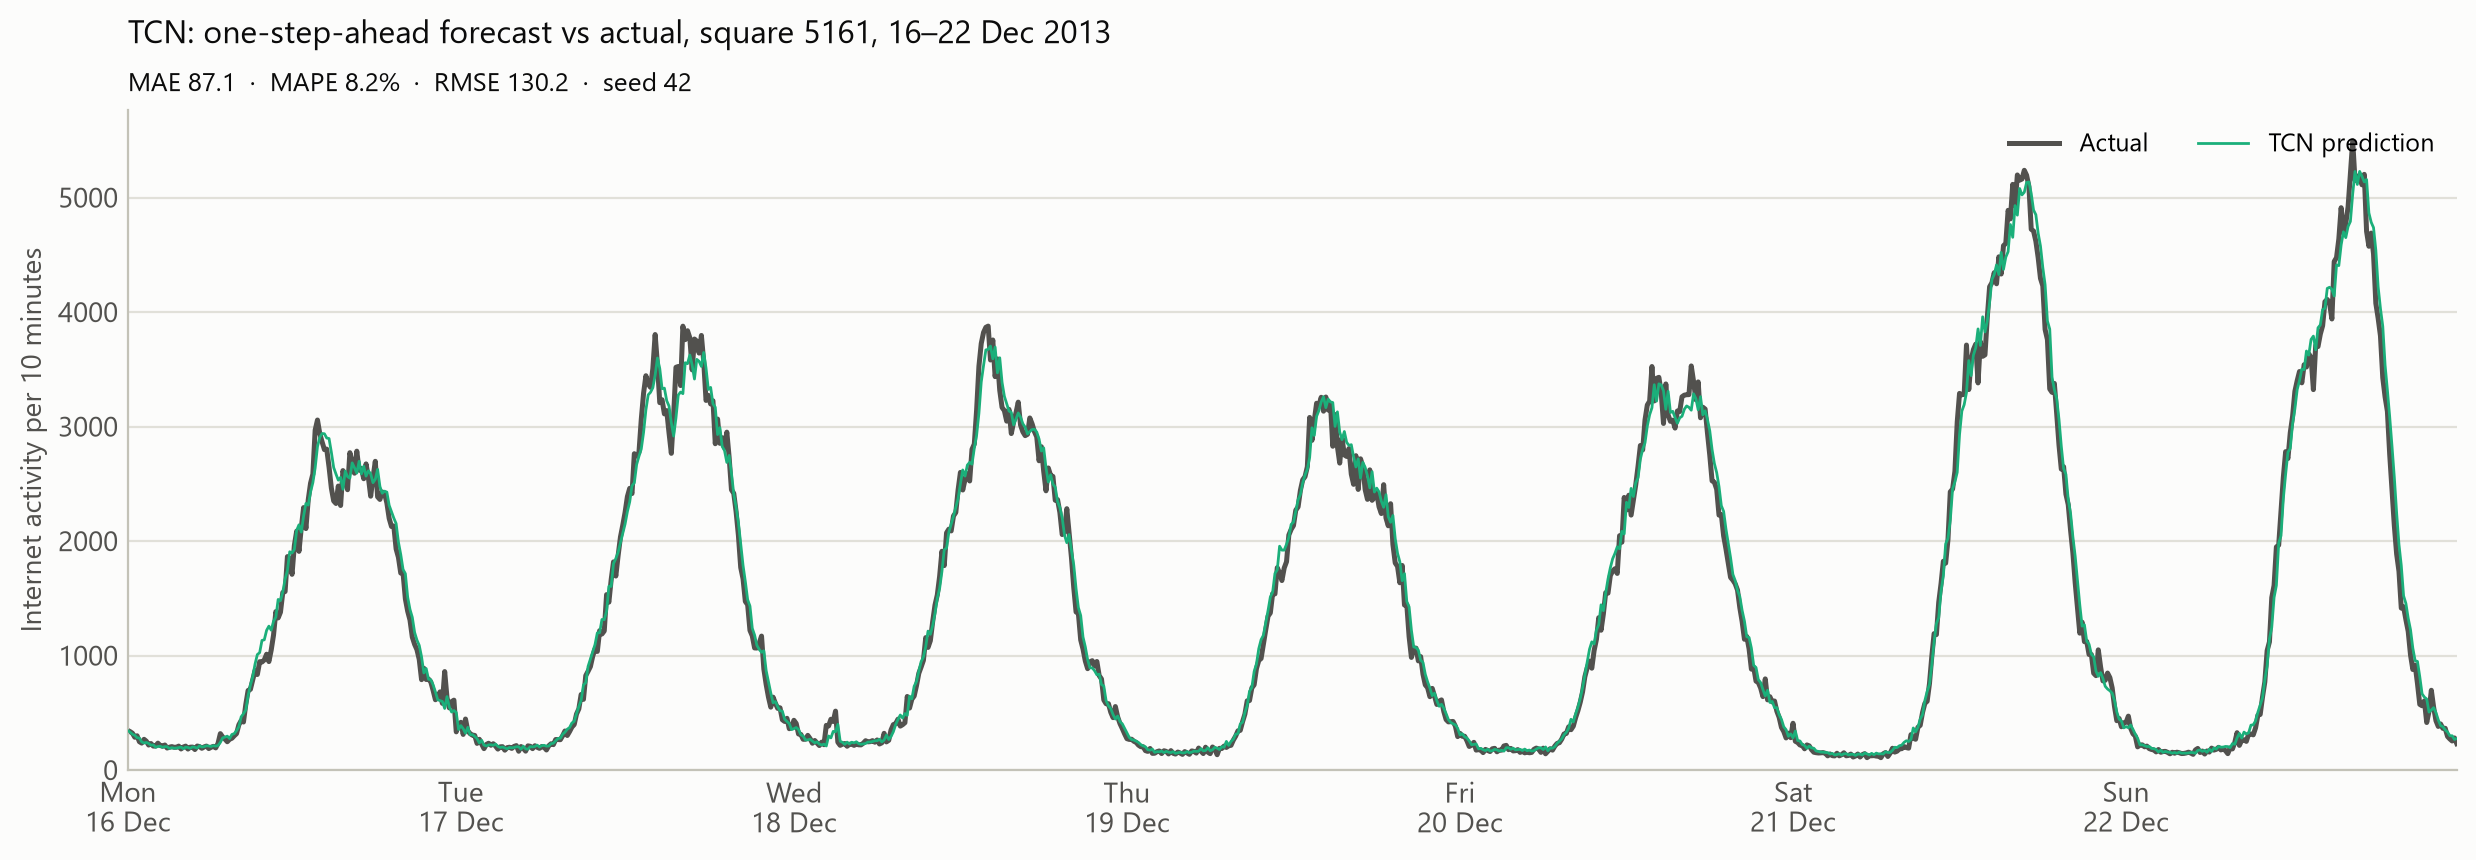

In [25]:
for model in ("arima", "lstm", "tcn"):
    show(config.FORECASTS_DIR / f"square_5161_{model}.png")

The plots for squares 5059 and 5259 are in `results/4_model_evaluation/forecasts/`, next to the
predictions for all three squares.

## 5. Where the models fail

The busiest square's worst stretch was the last weekend before Christmas, when its afternoon peaks
ran about 50% above those on weekdays. Across every square and model, the biggest errors share one cause:
traffic jumped or dropped sharply within ten minutes and the forecast fell short of the move.

In [26]:
failure = read_json(config.FAILURE_ANALYSIS_DIR / "summary.json")
pd.DataFrame(failure["5161"]["mae_by_day"]).round(1)

,naive,arima,lstm,tcn
Mon 16,854.9,61.4,83.2,80.5
Tue 17,316.1,77.9,99.8,90.4
Wed 18,202.6,77.0,106.0,80.1
Thu 19,201.3,65.8,70.8,76.8
Fri 20,132.2,63.5,76.5,78.6
Sat 21,503.0,92.4,100.1,98.0
Sun 22,160.1,100.0,113.3,104.8


In [27]:
pd.DataFrame({
    (square, model): values
    for square in ("5161", "5059", "5259")
    for model, values in failure[square]["reaction"].items()
}).T.drop(columns="largest_share").round(3)

under_reaction_share_all  under_reaction_share_largest  \
5161 arima                     0.812                         1.000   
     lstm                      0.761                         0.980   
     tcn                       0.782                         1.000   
5059 arima                     0.796                         1.000   
     lstm                      0.734                         0.941   
     tcn                       0.775                         1.000   
5259 arima                     0.814                         0.980   
     lstm                      0.817                         0.980   
     tcn                       0.827                         1.000   

            corr_abs_error_abs_move  
5161 arima                    0.729  
     lstm                     0.642  
     tcn                      0.724  
5059 arima                    0.745  
     lstm                     0.581  
     tcn                      0.666  
5259 arima                    0.653  
     lstm                     0.649  
     tcn                      0.679

In [28]:
pd.DataFrame(failure["5161"]["largest_arima_misses"]).head(5)

,time,actual,previous_actual,arima,lstm,tcn,abs_error
0,Sat 21 13:20,3381.3,3720.0,4017.3,3872.8,3852.9,636.0
1,Tue 17 15:30,3517.7,3100.9,2973.2,3047.1,3075.0,544.5
2,Sun 22 13:30,3322.6,3604.9,3856.9,3811.4,3790.1,534.3
3,Sat 21 18:30,3328.4,3759.3,3806.2,3796.3,3850.9,477.8
4,Sat 21 12:40,3323.2,3712.0,3799.6,3629.2,3576.6,476.4


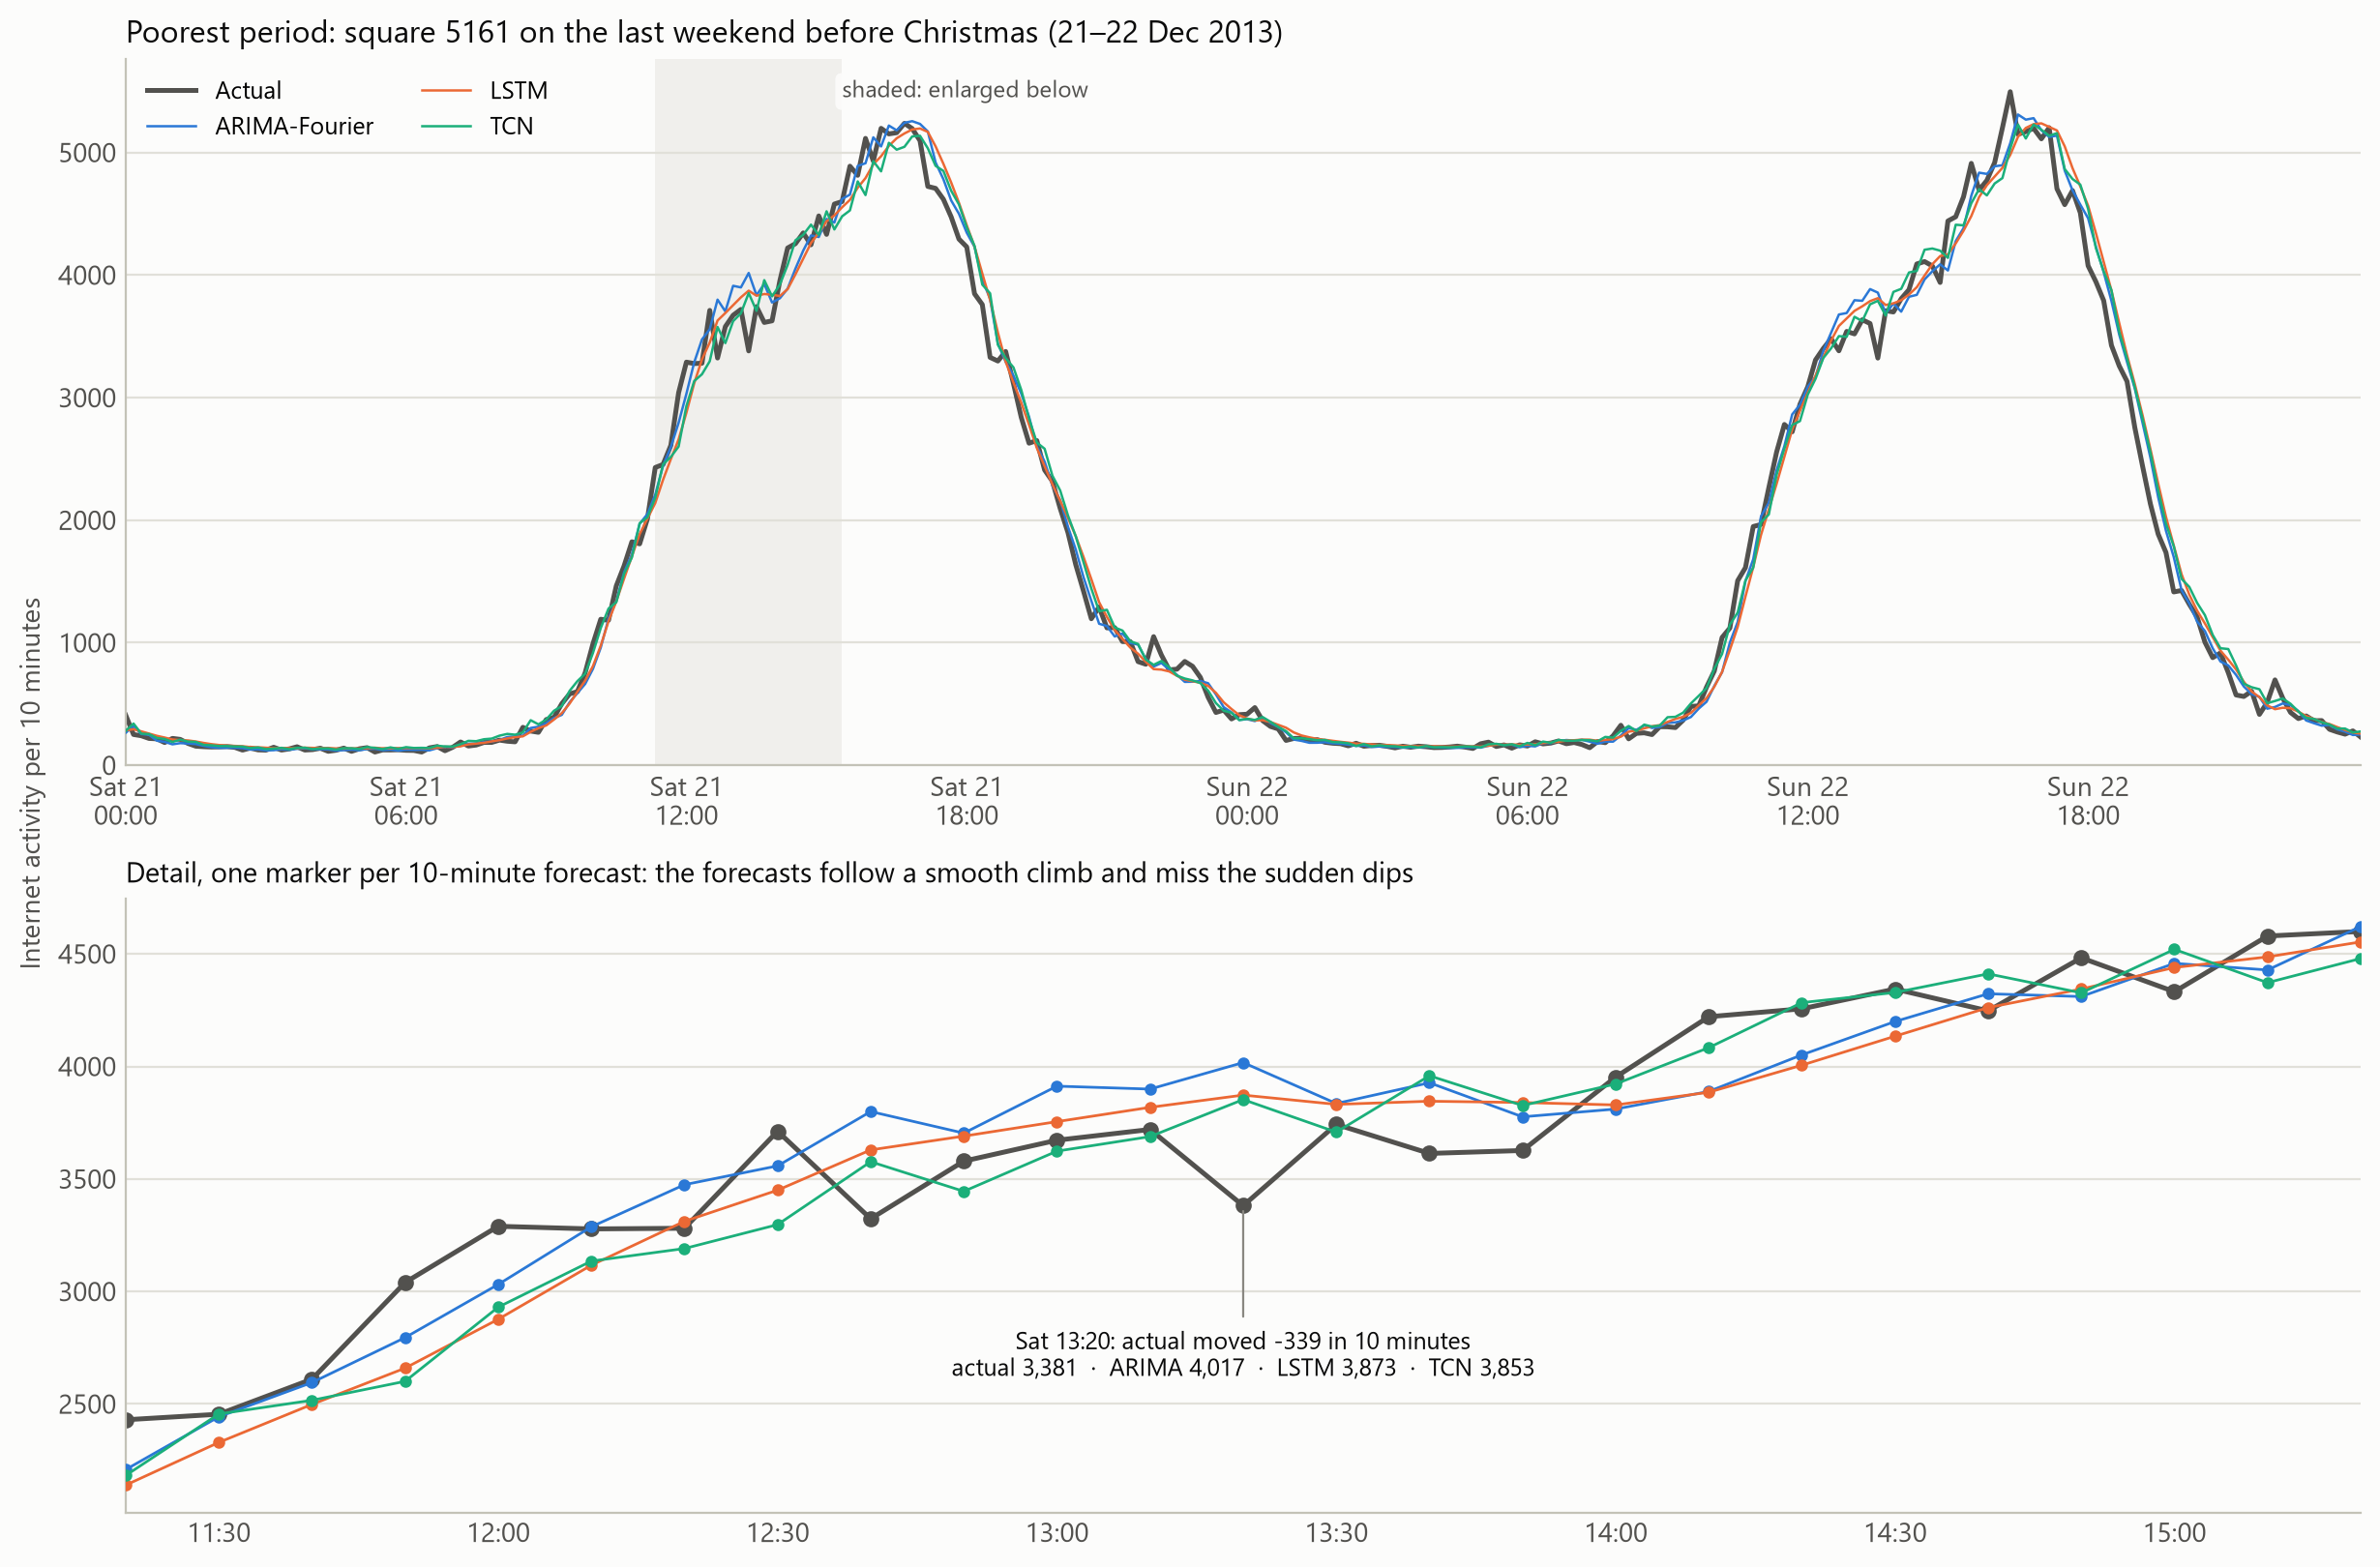

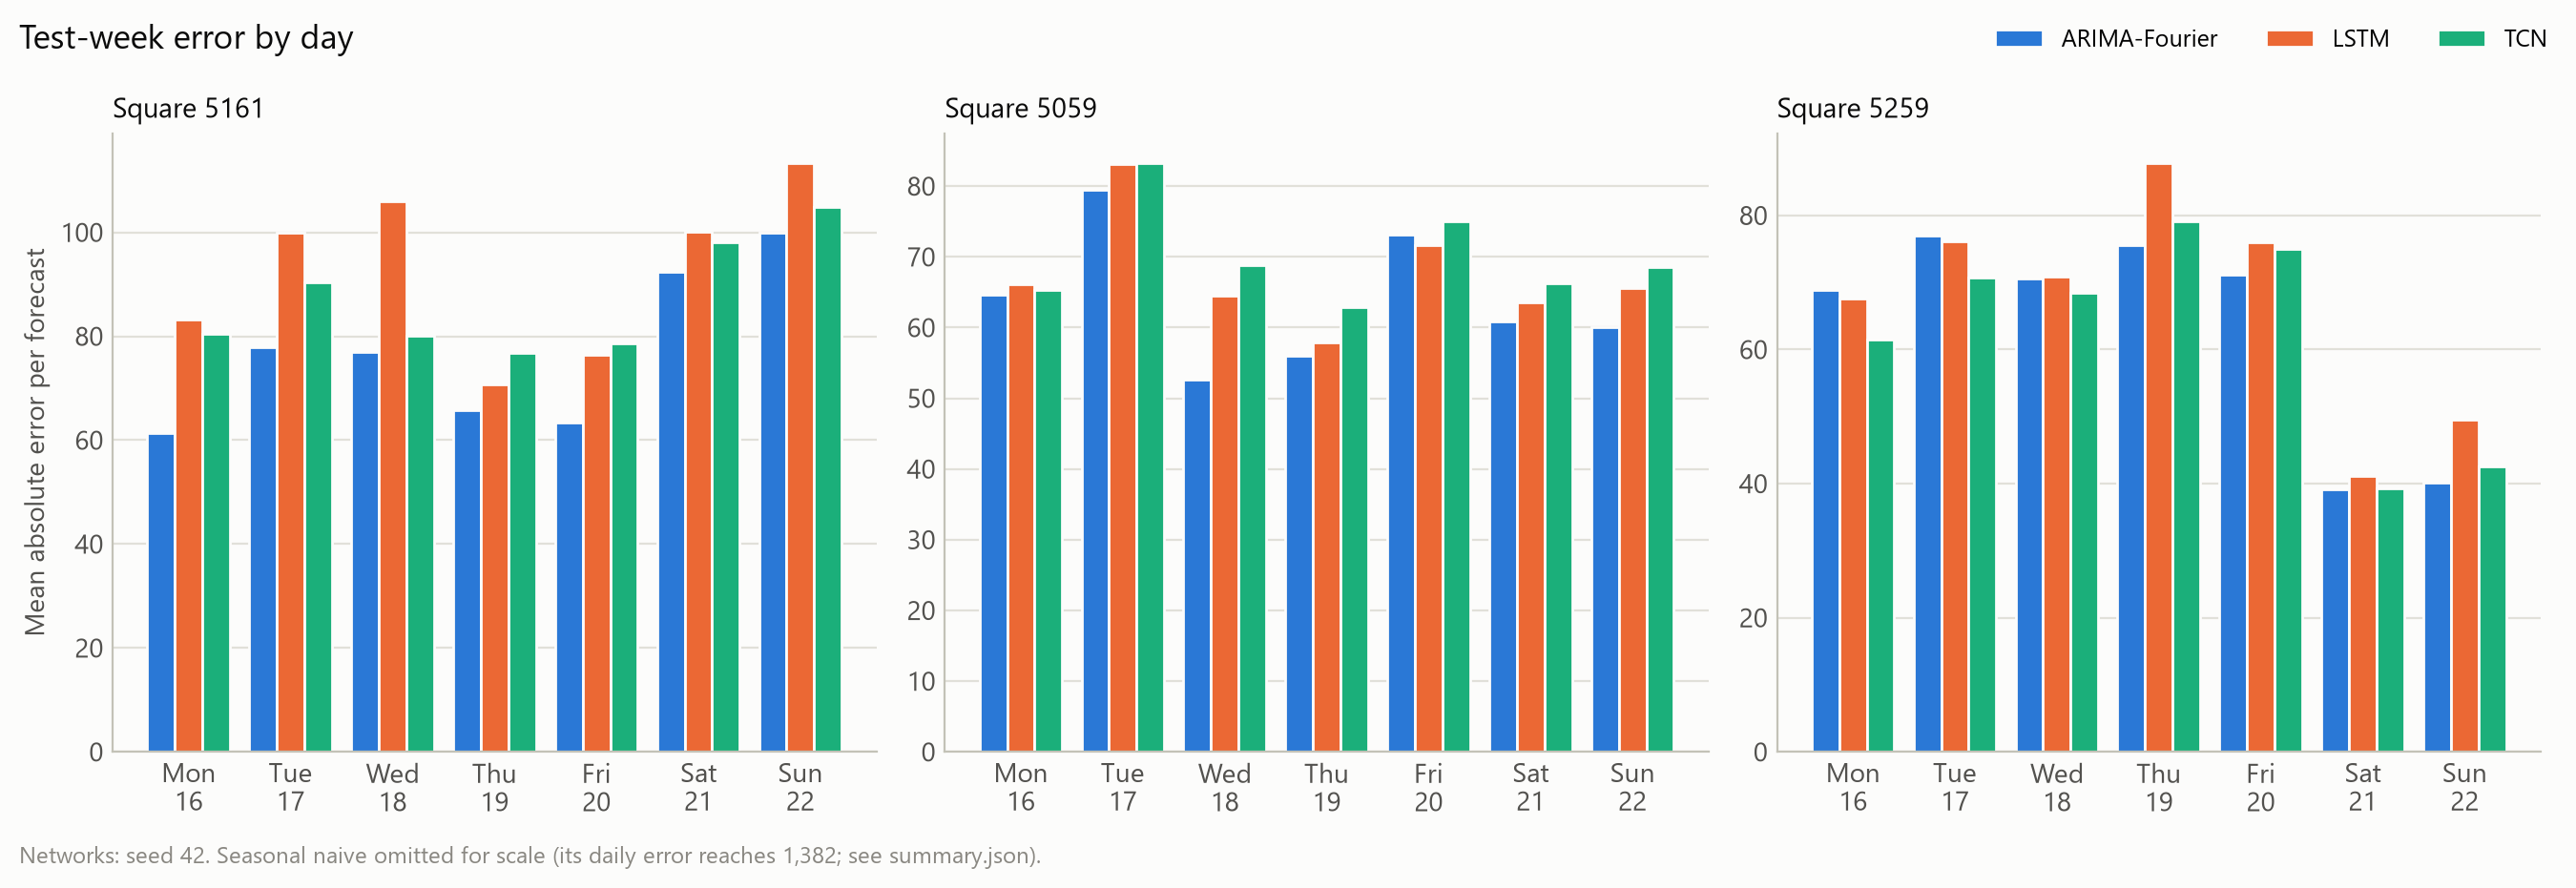

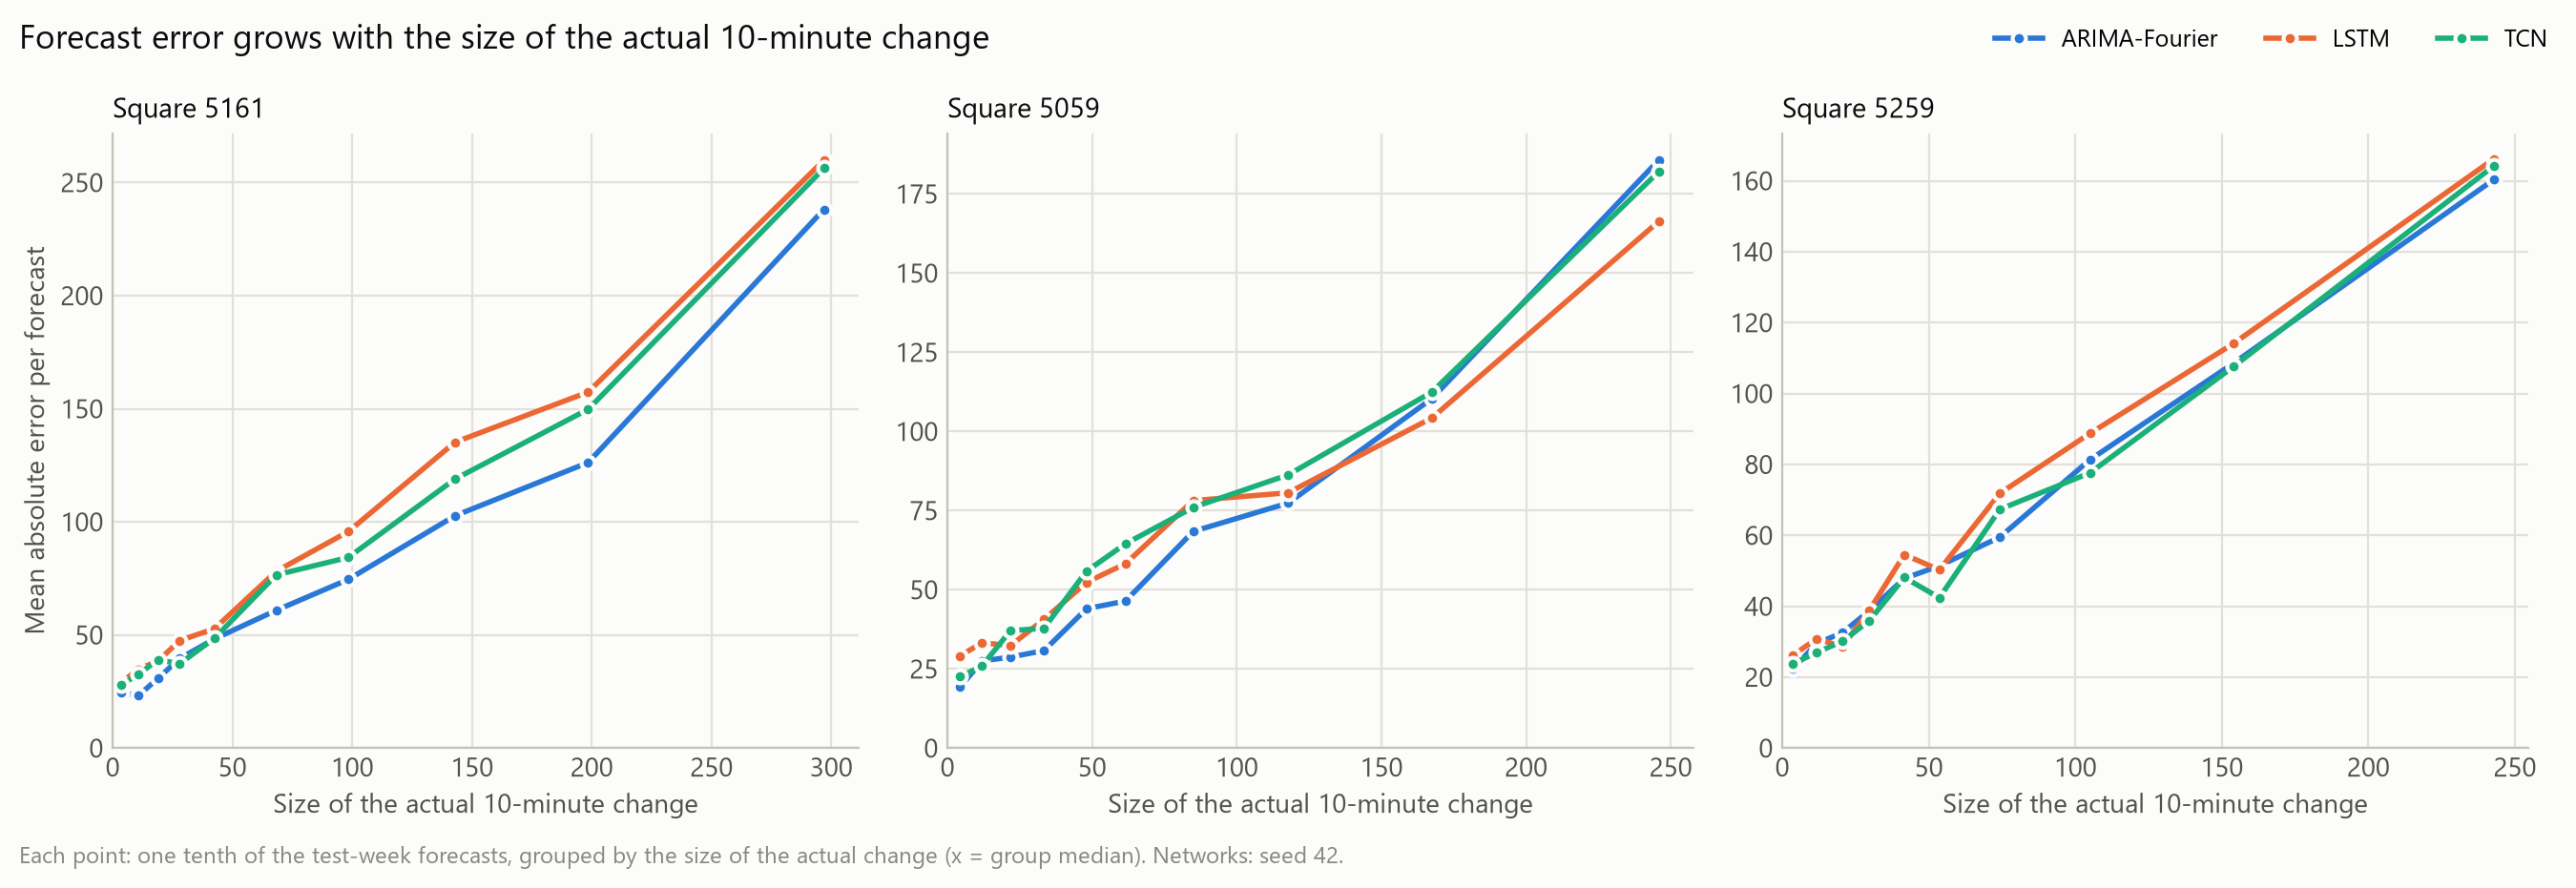

In [29]:
show(config.FAILURE_ANALYSIS_DIR / "poorest_period.png")
show(config.FAILURE_ANALYSIS_DIR / "error_by_day.png")
show(config.FAILURE_ANALYSIS_DIR / "error_vs_change_size.png")

## 6. Takeaways

ARIMA with Fourier terms came out ahead in every area, and it was also the cheapest to train.
The data explains why: the traffic is dominated by regular daily and weekly cycles plus
short-range memory, which is exactly the structure that model assumes. The networks had to learn
that structure from about 5,300 training windows, did slightly worse on unseen data, and in the
TCN's case varied a lot from one seed to the next.

The comparison has limits. It uses one test week, tuning was done on one area, the models only
see each area's own history, and the week-long input windows had fewer training examples than the
one-day ones. Holiday and calendar features, training across many areas at once, and a longer
test period would be the natural next steps.